In [29]:
import pandas as pd

#Load the analytical dataset
df = pd.read_csv("../data/processed/analytical_dataset.csv")

print("Analytical dataset shape:", df.shape)

Analytical dataset shape: (590540, 437)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 437 entries, TransactionID to DeviceInfo
dtypes: bool(1), float64(400), int64(4), object(32)
memory usage: 1.9+ GB


In [31]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [32]:
# Step 2: Data Validation

print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Duplicate TransactionIDs ===")
print(df["TransactionID"].duplicated().sum())

print("\n=== Target Distribution ===")
print(df["isFraud"].value_counts())

print("\n=== Target Percentage ===")
print((df["isFraud"].value_counts(normalize=True) * 100).round(2))

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

print("\n=== Top 20 Missing-Value Columns ===")
print(df.isna().sum().sort_values(ascending=False).head(20))

=== Dataset Shape ===
(590540, 437)

=== Duplicate TransactionIDs ===
0

=== Target Distribution ===
isFraud
0    569877
1     20663
Name: count, dtype: int64

=== Target Percentage ===
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64

=== Data Types ===
float64    400
object      32
int64        4
bool         1
Name: count, dtype: int64

=== Top 20 Missing-Value Columns ===
id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_03    524216
id_04    524216
D6       517353
id_33    517251
id_10    515614
dtype: int64


In [33]:
# Step 3: Transaction Amount Analysis

print("=== Transaction Amount Summary ===")

print("\nOverall:")
print(df["TransactionAmt"].describe())

print("\nFraudulent transactions:")
print(
    df.loc[df["isFraud"] == 1, "TransactionAmt"]
    .describe()
)

print("\nLegitimate transactions:")
print(
    df.loc[df["isFraud"] == 0, "TransactionAmt"]
    .describe()
)

=== Transaction Amount Summary ===

Overall:
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

Fraudulent transactions:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64

Legitimate transactions:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


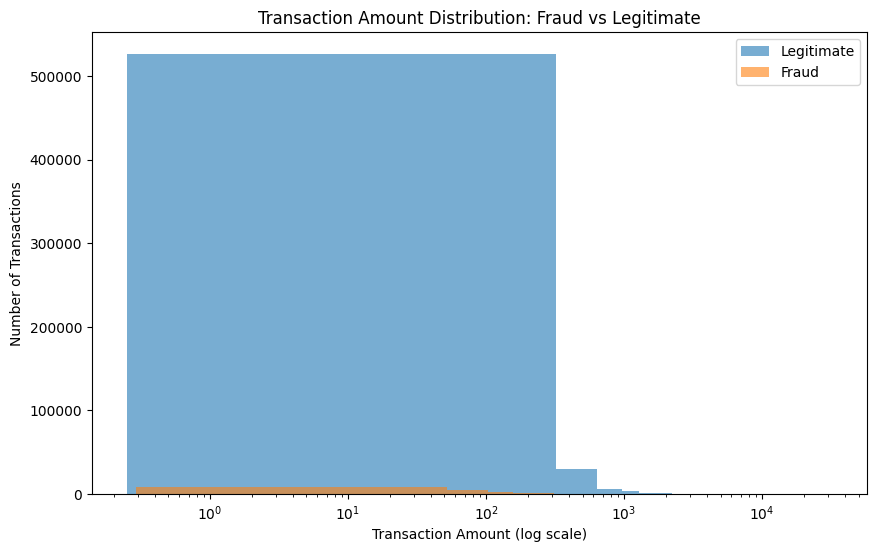

In [34]:
import matplotlib.pyplot as plt
# ============================================================
# Transaction Amount Distribution: Fraud vs Legitimate
# ============================================================

plt.figure(figsize=(10, 6))

# Plot legitimate transactions
plt.hist(
    df.loc[df["isFraud"] == 0, "TransactionAmt"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

# Plot fraudulent transactions
plt.hist(
    df.loc[df["isFraud"] == 1, "TransactionAmt"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

# Transaction amounts are highly right-skewed,
# so use a logarithmic scale to make the distribution easier to inspect.
plt.xscale("log")

plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution: Fraud vs Legitimate")
plt.legend()

plt.show()

### Fraud Rate Across Transaction Amount Ranges

The previous distribution showed that transaction amounts are highly right-skewed
and that fraudulent transactions are much less frequent than legitimate transactions.

Because raw transaction counts are dominated by legitimate transactions, the next
analysis compares the **fraud rate within different transaction-amount ranges**.

This helps determine whether transaction amount has a meaningful relationship with
fraud risk and whether certain amount ranges exhibit disproportionately high fraud
rates.

The analysis will use predefined transaction-amount bands rather than treating the
maximum observed fraudulent transaction as a fraud threshold.

A higher fraud rate within an amount range indicates an association with fraud, but
does not imply that transaction amount alone can determine whether a transaction is
fraudulent.

In [35]:
# ============================================================
# Fraud Rate by Transaction Amount Range
# ============================================================

# Create transaction amount bands.
# The final range is open-ended so that all transactions are included.
amount_bins = [0, 25, 50, 100, 250, 500, 1000, 2500, 5000, float("inf")]

amount_labels = [
    "0–25",
    "25–50",
    "50–100",
    "100–250",
    "250–500",
    "500–1,000",
    "1,000–2,500",
    "2,500–5,000",
    "5,000+"
]

df["amount_range"] = pd.cut(
    df["TransactionAmt"],
    bins=amount_bins,
    labels=amount_labels,
    right=False
)

# Calculate transaction count, fraud count, and fraud rate
amount_fraud = (
    df.groupby("amount_range", observed=True)["isFraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

# Convert fraud rate to percentage for easier interpretation
amount_fraud["fraud_rate"] = amount_fraud["fraud_rate"] * 100

print(amount_fraud)

              transaction_count  fraud_count  fraud_rate
amount_range                                            
0–25                      43329         3019    6.967620
25–50                    144186         4461    3.093920
50–100                   160742         4618    2.872927
100–250                  175923         5198    2.954702
250–500                   42036         2218    5.276430
500–1,000                 16744          962    5.745342
1,000–2,500                6601          163    2.469323
2,500–5,000                 961           23    2.393340
5,000+                       18            1    5.555556


## Transaction Amount Analysis — Findings

### Observation
- Transaction amounts are strongly right-skewed, with a mean of **135.03**
  and a median of **68.77** across all transactions.
- Fraudulent transactions have a slightly higher median amount (**75.00**)
  than legitimate transactions (**68.50**).
- Fraudulent transactions have a higher mean amount (**149.24**) than
  legitimate transactions (**134.51**).
- Fraud rates vary across transaction-amount ranges, but the relationship is
  **not linear or consistently increasing**.
- The highest observed fraud rate occurs in the **0–25** range at approximately
  **6.97%**, followed by the **500–1,000** range at approximately **5.75%**.
- The **5,000+** range has a fraud rate of approximately **5.56%**, but contains
  only 18 transactions and therefore provides insufficient evidence for a
  meaningful conclusion.

### Interpretation
Transaction amount shows some association with fraud, but there is no simple
relationship where larger transactions consistently imply higher fraud risk.

### Data-Science Implication
`TransactionAmt` should be retained as a candidate predictive feature.
Because its relationship with fraud appears non-linear and the distribution is
highly skewed, transformations and non-linear modeling approaches may be useful.

### Decision
- Retain `TransactionAmt`.
- Do not create a fixed fraud threshold based on transaction amount.
- Investigate a log-transformed amount during feature engineering.
- Allow the ML models to learn potentially non-linear relationships.

### Normalized Transaction Amount Distributions

The transaction dataset is highly imbalanced, with fraudulent transactions
representing only 3.5% of all observations.

Therefore, comparing raw transaction counts can obscure differences in the
distribution of transaction amounts between the two classes.

To address this, the next visualization normalizes each class separately.
This allows the shape of the transaction-amount distributions to be compared
independently of the number of observations in each class.

A logarithmic x-axis is used because transaction amounts are strongly
right-skewed.

The objective is to determine whether fraudulent and legitimate transactions
show noticeably different spending distributions, rather than assuming a
linear relationship between transaction amount and fraud.

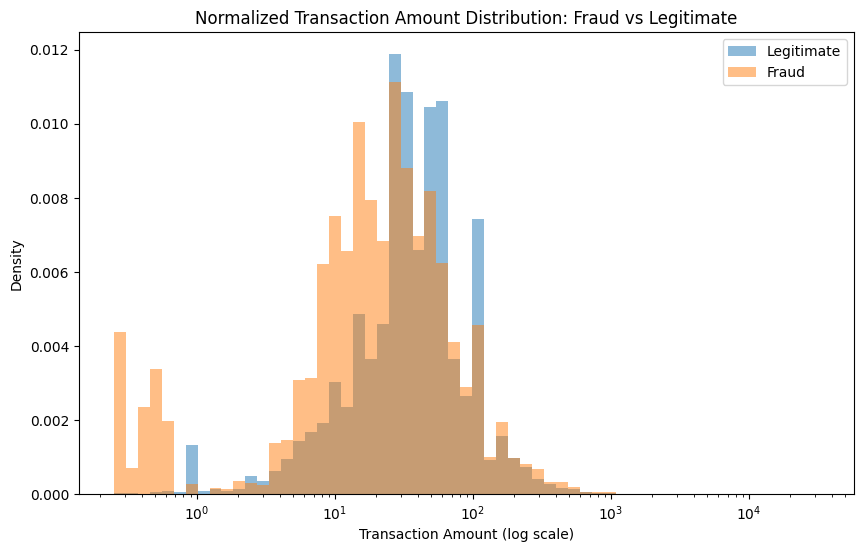

In [36]:
import numpy as np
# ============================================================
# Normalized Transaction Amount Distributions
# ============================================================

plt.figure(figsize=(10, 6))

# Separate transaction amounts by target class
fraud_amounts = df.loc[df["isFraud"] == 1, "TransactionAmt"]
legit_amounts = df.loc[df["isFraud"] == 0, "TransactionAmt"]

# Use the same bins for both classes so their distributions
# can be compared directly.
bins = np.logspace(
    np.log10(df["TransactionAmt"].min()),
    np.log10(df["TransactionAmt"].max()),
    60
)

# Normalize each class independently using density=True.
# This removes the effect of the large difference in class sizes.
plt.hist(
    legit_amounts,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    fraud_amounts,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Fraud"
)

# Use logarithmic scale because transaction amounts are highly right-skewed.
plt.xscale("log")

plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Density")
plt.title("Normalized Transaction Amount Distribution: Fraud vs Legitimate")
plt.legend()

plt.show()

## Transaction Amount Analysis — Final Findings

### Observation
- Transaction amounts are strongly right-skewed, with a median of **68.77**
  and a mean of **135.03** across all transactions.
- Fraudulent transactions have a slightly higher median (**75.00**) and mean
  (**149.24**) than legitimate transactions.
- Fraud rates vary substantially across transaction-amount ranges.
- The fraud rate is relatively high for very small transactions, decreases
  through several middle ranges, and increases again in some higher ranges.
- The normalized distributions also show that fraudulent transactions have a
  different amount distribution from legitimate transactions, particularly at
  the lower end.
- However, the two distributions overlap considerably across a wide range of
  transaction amounts.

### Interpretation
Transaction amount has an association with fraud, but the relationship is
**non-linear rather than consistently increasing or decreasing**.

The maximum observed fraudulent transaction amount of **5,191** should not be
interpreted as a fraud threshold because it represents only the largest fraud
observed in this dataset.

### Data-Science Implication
`TransactionAmt` is a useful candidate predictive feature, but it should not be
used as a standalone fraud rule.

Its skewed and potentially non-linear relationship with fraud suggests that
transformations such as a logarithmic transformation and non-linear models may
be useful during feature engineering and modeling.

### Decision
- Retain `TransactionAmt`.
- Do not create a fixed amount-based fraud threshold.
- Consider a log-transformed transaction amount during feature engineering.
- Allow the final ML models to learn non-linear relationships between
  transaction amount and fraud risk.

# Step 4 — Fraud Patterns Over Time

In [37]:
# ============================================================
# Step 4.1 — Transaction Time Overview
# ============================================================

# Examine the range and distribution of the relative transaction-time variable.
print("TransactionDT range:")
print("Minimum:", df["TransactionDT"].min())
print("Maximum:", df["TransactionDT"].max())

print("\nTransactionDT summary:")
print(df["TransactionDT"].describe())

TransactionDT range:
Minimum: 86400
Maximum: 15811131

TransactionDT summary:
count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


In [38]:
# ============================================================
# Step 4.1 — Convert TransactionDT to Days
# ============================================================

# TransactionDT is measured in seconds.
# Convert it into days relative to the first observed transaction.
df["transaction_day"] = (
    df["TransactionDT"] - df["TransactionDT"].min()
) / (24 * 60 * 60)

# Create weekly time periods for the analysis.
df["time_week"] = (df["transaction_day"] // 7).astype(int)

print("Observation period:")
print(f"{df['transaction_day'].min():.0f} to {df['transaction_day'].max():.0f} days")

print("\nNumber of weekly periods:")
print(df["time_week"].nunique())

Observation period:
0 to 182 days

Number of weekly periods:
26


In [39]:
# ============================================================
# Step 4.2 — Weekly Fraud Analysis
# ============================================================

# Aggregate transactions by week and calculate:
# - total number of transactions
# - number of fraudulent transactions
# - fraud rate
weekly_fraud = (
    df.groupby("time_week")["isFraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

# Convert fraud rate from proportion to percentage
weekly_fraud["fraud_rate"] = weekly_fraud["fraud_rate"] * 100

print(weekly_fraud)

           transaction_count  fraud_count  fraud_rate
time_week                                            
0                      27596          804    2.913466
1                      28463          717    2.519060
2                      35701          869    2.434105
3                      34906          724    2.074142
4                      24539          889    3.622805
5                      20919          803    3.838616
6                      20564          823    4.002140
7                      19761          862    4.362127
8                      21432          927    4.325308
9                      22534          996    4.419988
10                     20953          880    4.199876
11                     20175          676    3.350682
12                     22391          912    4.073065
13                     27429          884    3.222866
14                     21269          718    3.375805
15                     20891          866    4.145326
16                     21078

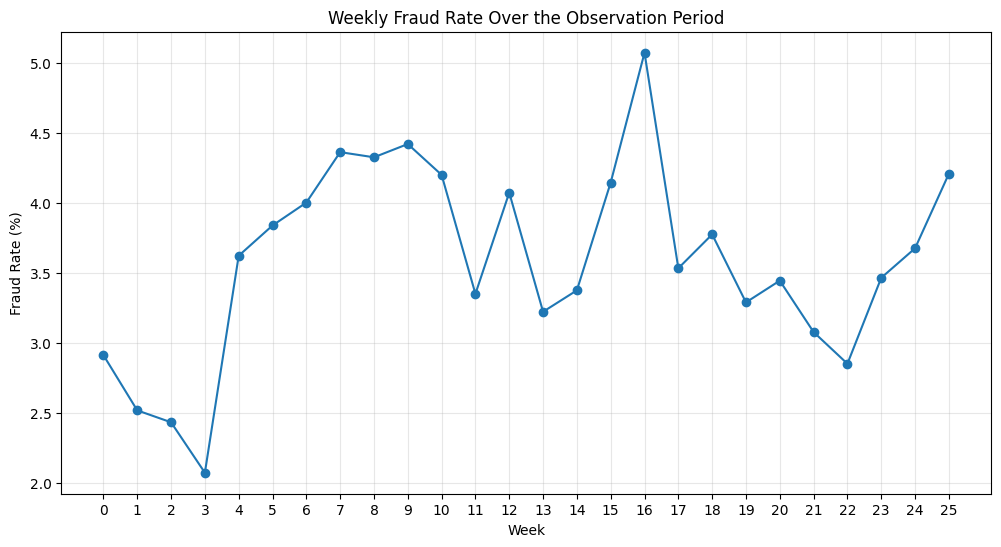

In [40]:
# ============================================================
# Weekly Fraud Rate Trend
# ============================================================

plt.figure(figsize=(12, 6))

# Plot fraud rate for each chronological week
plt.plot(
    weekly_fraud.index,
    weekly_fraud["fraud_rate"],
    marker="o"
)

plt.xlabel("Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Weekly Fraud Rate Over the Observation Period")
plt.xticks(weekly_fraud.index)

plt.grid(alpha=0.3)
plt.show()

## Fraud Patterns Over Time — Findings

### Observation

- The dataset covers approximately **182 days** of transaction activity.
- The weekly fraud rate varies considerably across the observation period.
- The lowest observed weekly fraud rate is approximately **2.07%**, while the
  highest is approximately **5.07%**.
- Fraud prevalence does not follow a consistent upward or downward trend.
- Instead, the fraud rate fluctuates across different periods, with several
  periods showing elevated fraud prevalence.

### Interpretation

Fraud prevalence is **not temporally stable** throughout the observation
period. However, the analysis only establishes an association between time
and fraud prevalence; it does not establish why the variation occurs.

### Data-Science Implication

Temporal variation means that the distribution of fraud in future transactions
may differ from the distribution observed in earlier transactions.

A random train-validation split could mix transactions from different time
periods and potentially provide an overly optimistic estimate of how the model
will perform on future transactions.

### Decision

- Retain `TransactionDT` as a candidate feature for temporal feature
  engineering.
- Use chronological train-validation splitting during model development.
- Evaluate model performance on a future time period rather than relying only
  on random validation.
- Investigate other transaction characteristics over time before attributing
  the observed variation to changes in fraud behavior.

# Step 5 — Categorical Features and Fraud Patterns

Categorical variables can capture differences in transaction, payment,
email, and device characteristics between fraudulent and legitimate
transactions.

The dataset contains several categorical features, but their usefulness
depends on factors such as:

- Number of unique categories
- Frequency of rare categories
- Missingness
- Fraud prevalence across categories
- Availability at the transaction prediction point

The initial analysis will therefore focus on the major interpretable
categorical features rather than assigning unsupported meanings to
anonymized variables.

The objective is to identify categorical variables that show meaningful
variation in fraud prevalence and may therefore be useful during feature
engineering.

In [49]:
# ============================================================
# Step 5.1 — Categorical Feature Overview
# ============================================================

# Identify all object/categorical columns in the analytical dataset
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Number of categorical columns:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)

print("\nUnique values per categorical column:")
for col in categorical_cols:
    print(f"{col:20} : {df[col].nunique(dropna=True):,}")

Number of categorical columns: 32

Categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'time_period', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Unique values per categorical column:
ProductCD            : 5
card4                : 4
card6                : 4
P_emaildomain        : 59
R_emaildomain        : 60
M1                   : 2
M2                   : 2
M3                   : 2
M4                   : 3
M5                   : 2
M6                   : 2
M7                   : 2
M8                   : 2
M9                   : 2
time_period          : 10
id_12                : 2
id_15                : 3
id_16                : 2
id_23                : 3
id_27                : 2
id_28                : 2
id_29                : 2
id_30                : 75
id_31                : 130
i

## Step 5.2 — Product and Payment Category Findings

### Observation

- Fraud prevalence differs substantially across `ProductCD`, `card4`, and `card6`.
- `ProductCD = C` has the highest observed fraud rate at approximately **11.69%**, while `ProductCD = W` has the lowest at approximately **2.04%**.
- Credit transactions have an observed fraud rate of **6.68%**, compared with **2.43%** for debit transactions.
- Therefore, the observed fraud rate for credit transactions is approximately **2.75 times higher** than for debit transactions.
- Debit transactions nevertheless account for slightly more total fraud cases because they represent a much larger share of all transactions.
- `discover` has the highest observed fraud rate among `card4` categories at approximately **7.73%**, but its transaction volume is substantially smaller than Visa and Mastercard.

### Interpretation

These categorical variables show meaningful associations with fraud prevalence.

However, the observed differences should not be interpreted as causal relationships. In particular, the anonymized `ProductCD` categories should not be assigned business meanings that are not provided by the dataset documentation.

### Data-Science Implication

`ProductCD`, `card4`, and `card6` are useful candidate features for fraud prediction.

The model may be able to combine these categorical signals with transaction amount, time, identity availability, and other features to identify higher-risk transactions.

### Decision

- Retain `ProductCD`.
- Retain `card4`.
- Retain `card6`.
- Treat missing categories explicitly during preprocessing.
- Do not create manual fraud rules such as "credit = fraud."
- Evaluate their predictive contribution together with other features during modeling.

In [48]:
# ============================================================
# Step 5.2 — Fraud Rate by Key Categorical Features
# ============================================================

key_categorical = ["ProductCD", "card4", "card6"]

for col in key_categorical:

    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")

    # Calculate transaction count, fraud count, and fraud rate
    category_fraud = (
        df.groupby(col, dropna=False)["isFraud"]
        .agg(
            transaction_count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .sort_values("fraud_rate", ascending=False)
    )

    # Convert fraud rate to percentage
    category_fraud["fraud_rate"] = (
        category_fraud["fraud_rate"] * 100
    )

    print(category_fraud)


ProductCD
           transaction_count  fraud_count  fraud_rate
ProductCD                                            
C                      68519         8008   11.687269
S                      11628          686    5.899553
H                      33024         1574    4.766231
R                      37699         1426    3.782594
W                     439670         8969    2.039939

card4
                  transaction_count  fraud_count  fraud_rate
card4                                                       
discover                       6651          514    7.728161
visa                         384767        13373    3.475610
mastercard                   189217         6496    3.433095
american express               8328          239    2.869837
NaN                            1577           41    2.599873

card6
                 transaction_count  fraud_count  fraud_rate
card6                                                      
credit                      148986         9950   

In [44]:
print("Dataset shape:", df.shape)

print("\nColumns related to our previous analysis:")
print([
    col for col in df.columns
    if col in ["has_identity", "time_period", "transaction_day", "time_week"]
])

Dataset shape: (590540, 440)

Columns related to our previous analysis:
['has_identity', 'time_period', 'transaction_day', 'time_week']


In [46]:
# Check which analysis-related columns are present in the saved dataset.
# We will decide later which are EDA-only and which may become model features.

analysis_columns = [
    "has_identity",
    "time_period",
    "transaction_day",
    "time_week"
]

for col in analysis_columns:
    print(f"{col}: {col in df.columns}")

has_identity: True
time_period: True
transaction_day: True
time_week: True


### Still there r 2 unknown columns that needs to be inspected

In [47]:
# Load only the column names from the original raw files.
# This does NOT load the datasets into memory.

raw_transaction_cols = pd.read_csv(
    "../data/raw/train_transaction.csv",
    nrows=0
).columns

raw_identity_cols = pd.read_csv(
    "../data/raw/train_identity.csv",
    nrows=0
).columns

original_columns = set(raw_transaction_cols).union(
    set(raw_identity_cols)
)

added_columns = [
    col for col in df.columns
    if col not in original_columns
]

print("Number of added columns:", len(added_columns))
print("\nAdded columns:")
print(added_columns)

Number of added columns: 6

Added columns:
['has_identity', 'time_period', 'time_days', 'amount_range', 'transaction_day', 'time_week']


## Step 5.3 — Email Domain Analysis Findings

### Observation

- Fraud prevalence varies across email-domain categories in both
  `P_emaildomain` and `R_emaildomain`.
- In `P_emaildomain`, `outlook.com` has an observed fraud rate of
  approximately **9.46%**, compared with **4.35%** for `gmail.com`.
- In `R_emaildomain`, `outlook.com` has an observed fraud rate of
  approximately **16.51%**, while `gmail.com` has approximately **11.92%**.
- Several other domains also show elevated fraud rates, although some have
  relatively small transaction counts.
- Missing `R_emaildomain` has a lower observed fraud rate (**2.08%**) than
  the overall dataset fraud rate (**3.50%**).

### Interpretation

Email-domain categories show an association with fraud prevalence, but the
relationship is not universal across domains.

The magnitude of the observed fraud rate should be interpreted together with
transaction volume because categories with small sample sizes can produce
unstable fraud-rate estimates.

### Data-Science Implication

Both `P_emaildomain` and `R_emaildomain` are useful candidate predictive
features.

Because they are relatively high-cardinality categorical variables, they
should not automatically be represented using unrestricted one-hot encoding.
Rare-category handling or alternative categorical representations may be
evaluated during feature engineering.

### Decision

- Retain `P_emaildomain`.
- Retain `R_emaildomain`.
- Treat missing values as an explicit category during preprocessing.
- Evaluate rare-category handling during feature engineering.
- Do not create manual fraud rules based on individual email domains.
- Evaluate predictive contribution and temporal stability before final feature
  selection.

In [50]:
# Step 5.3: Email domain fraud analysis

email_features = ["P_emaildomain", "R_emaildomain"]

for col in email_features:

    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")

    email_fraud = (
        df.groupby(col, dropna=False)["isFraud"]
        .agg(
            transaction_count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .sort_values(
            ["transaction_count", "fraud_rate"],
            ascending=[False, False]
        )
    )

    email_fraud["fraud_rate"] = (
        email_fraud["fraud_rate"] * 100
    )

    print("Number of categories:", df[col].nunique(dropna=False))

    print("\nTop categories by transaction volume:")
    print(email_fraud.head(15))

    print("\nCategories with at least 500 transactions, ranked by fraud rate:")
    print(
        email_fraud[
            email_fraud["transaction_count"] >= 500
        ]
        .sort_values("fraud_rate", ascending=False)
        .head(15)
    )


P_emaildomain
Number of categories: 60

Top categories by transaction volume:
               transaction_count  fraud_count  fraud_rate
P_emaildomain                                            
gmail.com                 228355         9943    4.354185
yahoo.com                 100934         2297    2.275745
NaN                        94456         2790    2.953756
hotmail.com                45250         2396    5.295028
anonymous.com              36998          859    2.321747
aol.com                    28289          617    2.181060
comcast.net                 7888          246    3.118661
icloud.com                  6267          197    3.143450
outlook.com                 5096          482    9.458399
msn.com                     4092           90    2.199413
att.net                     4033           30    0.743863
live.com                    3041           84    2.762249
sbcglobal.net               2970           12    0.404040
verizon.net                 2705           22    0.

## Step 5.4 — M-Feature Analysis Findings

### Observation

- The anonymized M-features show varying levels of association with fraud.
- Several features show substantial differences in observed fraud rates across
  their categories.
- `M4` shows particularly strong separation, with the `M2` category having an
  observed fraud rate of approximately **11.37%**, compared with **3.66%** for
  `M0` and **2.71%** for `M1`.
- `M6` also shows substantial separation, with a fraud rate of approximately
  **7.07%** when the feature is missing compared with **1.70%** for category `T`.
- Several other M-features show higher fraud prevalence when their values are
  missing.
- `M5` shows comparatively weak separation because its `T` and missing
  categories have very similar fraud rates.

### Interpretation

The M-features contain potentially useful predictive information, including
information represented by their missingness patterns.

Because these variables are anonymized, their categories will be interpreted
only statistically. No business meaning will be assigned to `M1`–`M9` without
reliable documentation.

### Data-Science Implication

M-features may contribute useful signals to a fraud prediction model.

The differences observed across categories suggest that categorical encoding
and explicit missing-value handling should be considered during feature
engineering.

A feature with weak univariate association should not automatically be
discarded because its predictive contribution may change when combined with
other variables.

### Decision

- Retain `M1`–`M9` as candidate features initially.
- Treat missing values explicitly during preprocessing.
- Do not assign unsupported business meanings to the anonymized categories.
- Evaluate their contribution during model development.
- Reconsider weak or redundant features after multivariate modeling and
  feature-selection analysis.

In [51]:
# Step 5.4: M-feature fraud analysis

m_features = [f"M{i}" for i in range(1, 10)]

for col in m_features:

    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")

    m_fraud = (
        df.groupby(col, dropna=False)["isFraud"]
        .agg(
            transaction_count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .sort_values("fraud_rate", ascending=False)
    )

    m_fraud["fraud_rate"] = m_fraud["fraud_rate"] * 100

    print(m_fraud)


M1
     transaction_count  fraud_count  fraud_rate
M1                                             
NaN             271100        14321    5.282553
T               319415         6342    1.985505
F                   25            0    0.000000

M2
     transaction_count  fraud_count  fraud_rate
M2                                             
NaN             271100        14321    5.282553
F                33972         1184    3.485223
T               285468         5158    1.806858

M3
     transaction_count  fraud_count  fraud_rate
M3                                             
NaN             271100        14321    5.282553
F                67709         2049    3.026186
T               251731         4293    1.705392

M4
     transaction_count  fraud_count  fraud_rate
M4                                             
M2               59865         6809   11.373925
M0              196405         7198    3.664876
M1               52826         1429    2.705107
NaN             281444  

### DeviceType Findings

- `DeviceType` shows a noticeable association with fraud prevalence.
- Mobile transactions have an observed fraud rate of **10.17%**, compared
  with **6.52%** for desktop transactions.
- Therefore, the observed fraud rate for mobile transactions is approximately
  **1.56 times** the rate for desktop transactions.
- Mobile transactions also have slightly more observed fraud cases than
  desktop transactions, despite having fewer total transactions.
- Transactions with missing device type have a substantially lower observed
  fraud rate of **2.10%**.
- These differences represent associations with fraud and should not be
  interpreted as evidence that a particular device type causes fraud.

### Data-Science Decision

- Retain `DeviceType` as a candidate predictive feature.
- Treat missing device type explicitly during preprocessing.
- Do not create a manual rule such as "mobile = high risk."
- Allow the model to combine device information with other transaction,
  identity, payment, and behavioral features.

In [52]:
# Step 5.5.1: DeviceType fraud analysis

device_type_fraud = (
    df.groupby("DeviceType", dropna=False)["isFraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
    .sort_values("fraud_rate", ascending=False)
)

device_type_fraud["fraud_rate"] = (
    device_type_fraud["fraud_rate"] * 100
)

print(device_type_fraud)

            transaction_count  fraud_count  fraud_rate
DeviceType                                            
mobile                  55645         5657   10.166232
desktop                 85165         5554    6.521458
NaN                    449730         9452    2.101705


In [53]:
# Step 5.5.2: DeviceInfo frequency analysis

device_info_counts = (
    df["DeviceInfo"]
    .value_counts(dropna=False)
)

print("Total categories including missing:", len(device_info_counts))

print("\nTop 20 DeviceInfo values by transaction volume:")
print(device_info_counts.head(20))

print("\nRare DeviceInfo values:")
print("Values appearing only once:", (device_info_counts == 1).sum())
print("Values appearing <= 5 times:", (device_info_counts <= 5).sum())
print("Values appearing > 100 times:", (device_info_counts > 100).sum())

Total categories including missing: 1787

Top 20 DeviceInfo values by transaction volume:
DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
SM-G950U Build/NRD90M             290
SM-G930V Build/NRD90M             274
rv:58.0                           269
rv:52.0                           256
SAMSUNG                           235
Name: count, dtype: int64

Rare DeviceInfo values:
Values appearing only once: 440
Values appearing <= 5 times: 1018
Values appearing > 100

In [57]:
# Step 5.5.3: DeviceInfo fraud-rate analysis

device_info_fraud = (
    df.groupby("DeviceInfo", dropna=False)["isFraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

device_info_fraud["fraud_rate"] = (
    device_info_fraud["fraud_rate"] * 100
)

# Keep only sufficiently common DeviceInfo values
device_info_common = device_info_fraud[
    device_info_fraud["transaction_count"] >= 100
].sort_values(
    "fraud_rate",
    ascending=False
)

print("DeviceInfo values with at least 100 transactions:")
print(len(device_info_common))

print("\nTop 20 DeviceInfo values by fraud rate:")
print(device_info_common.head(20))

print("\nBottom 20 DeviceInfo values by fraud rate:")
print(device_info_common.tail(20))

DeviceInfo values with at least 100 transactions:
64

Top 20 DeviceInfo values by fraud rate:
                                     transaction_count  fraud_count  \
DeviceInfo                                                            
hi6210sft Build/MRA58K                             190          180   
SM-A300H Build/LRX22G                              203          169   
SM-J320M Build/LMY47V                              171           57   
WAS-LX3 Build/HUAWEIWAS-LX3                        108           28   
Moto Z2 Play Build/NPSS26.118-19-14                129           30   
Moto E (4) Plus Build/NMA26.42-69                  160           32   
SM-J701M Build/NRD90M                              154           30   
SM-G955F Build/NRD90M                              134           26   
Moto E (4) Build/NMA26.42-69                       125           23   
SM-A720F Build/NRD90M                              120           22   
Moto G (4) Build/NPJ25.93-14.7                     219

In [58]:
# Step 5.5.4: Check temporal stability of high-risk DeviceInfo values

high_risk_devices = [
    "hi6210sft Build/MRA58K",
    "SM-A300H Build/LRX22G",
    "SM-J320M Build/LMY47V"
]

for device in high_risk_devices:

    device_data = df[df["DeviceInfo"] == device].copy()

    print(f"\n{'=' * 70}")
    print(f"DeviceInfo: {device}")
    print(f"{'=' * 70}")

    print("\nOverall:")
    print(
        device_data["isFraud"].agg(["count", "sum", "mean"])
    )

    print("\nFraud rate by week:")
    weekly_device = (
        device_data.groupby("time_week")["isFraud"]
        .agg(
            transaction_count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
    )

    weekly_device["fraud_rate"] *= 100

    print(weekly_device)


DeviceInfo: hi6210sft Build/MRA58K

Overall:
count    190.000000
sum      180.000000
mean       0.947368
Name: isFraud, dtype: float64

Fraud rate by week:
           transaction_count  fraud_count  fraud_rate
time_week                                            
1                          2            0    0.000000
2                          1            0    0.000000
4                          1            0    0.000000
7                          1            0    0.000000
8                         45           45  100.000000
9                         86           85   98.837209
10                        50           50  100.000000
11                         1            0    0.000000
18                         1            0    0.000000
19                         2            0    0.000000

DeviceInfo: SM-A300H Build/LRX22G

Overall:
count    203.000000
sum      169.000000
mean       0.832512
Name: isFraud, dtype: float64

Fraud rate by week:
           transaction_count  fraud_cou

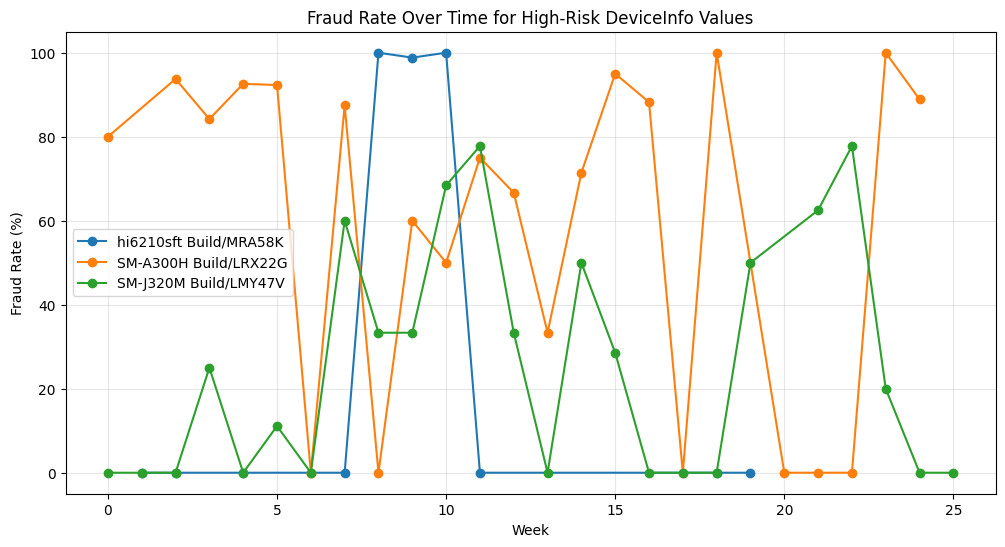

In [59]:
# Step 5.5.4: Temporal stability of high-risk DeviceInfo values

high_risk_devices = [
    "hi6210sft Build/MRA58K",
    "SM-A300H Build/LRX22G",
    "SM-J320M Build/LMY47V"
]

plt.figure(figsize=(12, 6))

for device in high_risk_devices:

    device_data = df[df["DeviceInfo"] == device]

    weekly_device = (
        device_data.groupby("time_week")["isFraud"]
        .mean() * 100
    )

    plt.plot(
        weekly_device.index,
        weekly_device.values,
        marker="o",
        label=device
    )

plt.xlabel("Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Over Time for High-Risk DeviceInfo Values")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

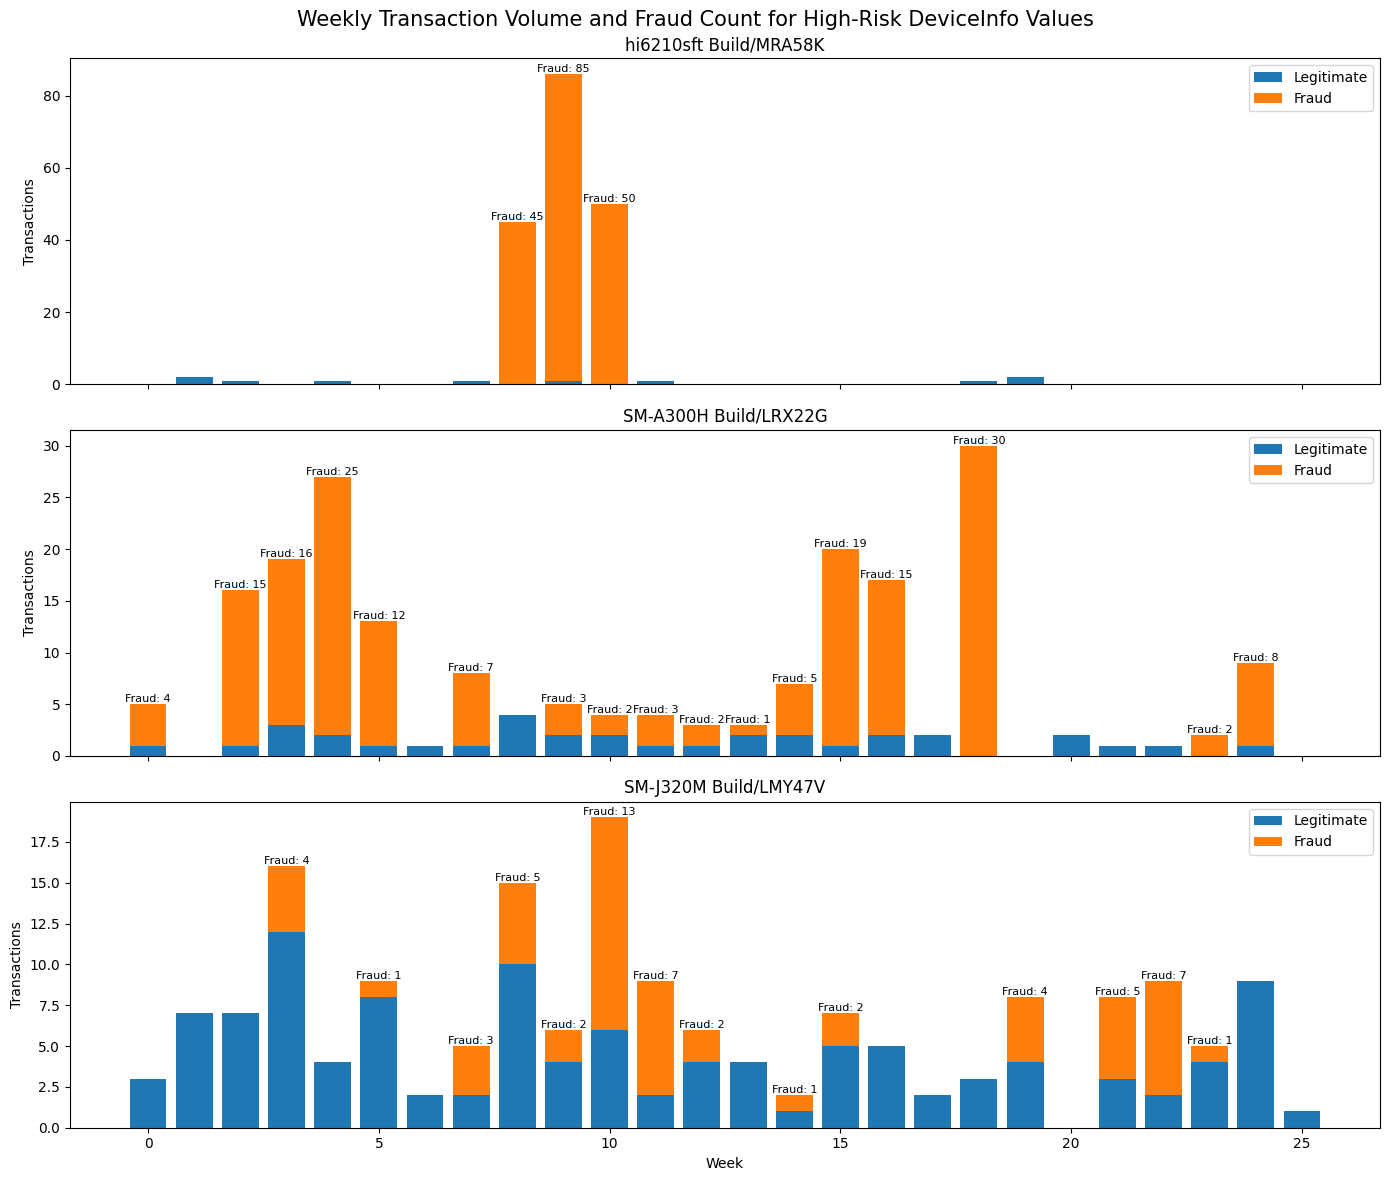

In [60]:
# Step 5.5.4: Weekly transaction volume and fraud count for high-risk devices

high_risk_devices = [
    "hi6210sft Build/MRA58K",
    "SM-A300H Build/LRX22G",
    "SM-J320M Build/LMY47V"
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 12),
    sharex=True
)

for ax, device in zip(axes, high_risk_devices):

    device_data = df[df["DeviceInfo"] == device]

    weekly_device = (
        device_data.groupby("time_week")["isFraud"]
        .agg(
            transaction_count="count",
            fraud_count="sum"
        )
    )

    weekly_device["legitimate_count"] = (
        weekly_device["transaction_count"]
        - weekly_device["fraud_count"]
    )

    ax.bar(
        weekly_device.index,
        weekly_device["legitimate_count"],
        label="Legitimate"
    )

    ax.bar(
        weekly_device.index,
        weekly_device["fraud_count"],
        bottom=weekly_device["legitimate_count"],
        label="Fraud"
    )

    # Display fraud count above each weekly bar
    for week, row in weekly_device.iterrows():
        if row["fraud_count"] > 0:
            ax.text(
                week,
                row["transaction_count"],
                f"Fraud: {int(row['fraud_count'])}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_title(device)
    ax.set_ylabel("Transactions")
    ax.legend()

axes[-1].set_xlabel("Week")

fig.suptitle(
    "Weekly Transaction Volume and Fraud Count for High-Risk DeviceInfo Values",
    fontsize=15
)

plt.tight_layout()
plt.show()


## Step 5.5 — Device Features: Final Findings

### Observation

- `DeviceInfo` is a high-cardinality categorical feature with **1,786 unique
  non-missing values** and substantial fragmentation.
- Despite this fragmentation, several DeviceInfo categories show strong
  associations with fraud.
- `hi6210sft Build/MRA58K` has **180 fraudulent transactions out of 190
  transactions**, corresponding to an observed fraud rate of **94.74%**.
- `SM-A300H Build/LRX22G` has **169 fraudulent transactions out of 203
  transactions**, corresponding to an observed fraud rate of **83.25%**.
- `SM-J320M Build/LMY47V` has **57 fraudulent transactions out of 171
  transactions**, corresponding to an observed fraud rate of **33.33%**.
- The weekly volume analysis shows that the extreme fraud rates for the first
  two devices are supported by meaningful transaction counts across multiple
  periods rather than being caused exclusively by isolated one-transaction
  observations.
- However, individual weekly fraud rates can still fluctuate substantially,
  particularly for lower-volume categories.

### Interpretation

DeviceInfo contains potentially strong predictive information about fraud
risk. Some device values are associated with substantially higher observed
fraud prevalence than the overall dataset.

The temporal analysis suggests that at least some high-risk DeviceInfo values
appear across multiple periods rather than being restricted to a single
time window.

However, these observations establish association, not causation, and the
anonymized device values should not be interpreted as inherently fraudulent
devices.

### Data-Science Implication

DeviceInfo should not be discarded simply because it has high cardinality.

Instead, its representation should account for:

- Category frequency
- Rare categories
- Missingness
- Temporal stability
- Predictive contribution
- Potential target leakage

A historical device-level fraud statistic may be useful during feature
engineering, but it must be calculated using only information available
before the transaction being scored.

### Decision

- Retain `DeviceInfo` as a candidate predictive feature.
- Do not blindly one-hot encode all DeviceInfo categories.
- Investigate rare-category grouping and frequency-based representations.
- Consider leakage-safe historical encoding during feature engineering.
- Evaluate the feature using temporal validation.
- Do not create manual rules such as "high-risk device = fraud."

In [61]:
# Step 5.6.1: Identify categorical id_* features

categorical_id_features = [
    col for col in df.columns
    if col.startswith("id_") and df[col].dtype == "object"
]

print("Categorical id_* features:")
print(categorical_id_features)

print("\nNumber of categorical id_* features:",
      len(categorical_id_features))

print("\nUnique values:")
for col in categorical_id_features:
    print(f"{col}: {df[col].nunique(dropna=False)}")

Categorical id_* features:
['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

Number of categorical id_* features: 15

Unique values:
id_12: 3
id_15: 4
id_16: 3
id_23: 4
id_27: 3
id_28: 3
id_29: 3
id_30: 76
id_31: 131
id_33: 261
id_34: 5
id_35: 3
id_36: 3
id_37: 3
id_38: 3


In [65]:
df.dtypes.value_counts()

float64     401
object       32
int64         5
bool          1
category      1
Name: count, dtype: int64

## Step 5.6.2 — Categorical Identity Feature Analysis

The categorical identity features will be compared using transaction volume,
fraud count, and observed fraud rate.

Because the identity variables are anonymized, the analysis focuses on their
statistical association with fraud rather than assigning business meanings
to individual categories.

Categories with very small transaction counts will be interpreted cautiously,
as their observed fraud rates may be unstable.

In [66]:
# Step 5.6.2: Fraud analysis across categorical id_* features

for col in categorical_id_features:

    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")

    id_fraud = (
        df.groupby(col, dropna=False)["isFraud"]
        .agg(
            transaction_count="count",
            fraud_count="sum",
            fraud_rate="mean"
        )
        .sort_values(
            ["transaction_count", "fraud_rate"],
            ascending=[False, False]
        )
    )

    id_fraud["fraud_rate"] = id_fraud["fraud_rate"] * 100

    print("Number of categories:", df[col].nunique(dropna=False))

    print("\nCategories with at least 500 transactions:")
    print(
        id_fraud[
            id_fraud["transaction_count"] >= 500
        ].sort_values(
            "fraud_rate",
            ascending=False
        )
    )


id_12
Number of categories: 3

Categories with at least 500 transactions:
          transaction_count  fraud_count  fraud_rate
id_12                                               
NotFound             123025        10049    8.168258
Found                 21208         1269    5.983591
NaN                  446307         9345    2.093850

id_15
Number of categories: 4

Categories with at least 500 transactions:
         transaction_count  fraud_count  fraud_rate
id_15                                              
Found                67728         7118   10.509686
Unknown              11645         1070    9.188493
New                  61612         3034    4.924365
NaN                 449555         9441    2.100077

id_16
Number of categories: 3

Categories with at least 500 transactions:
          transaction_count  fraud_count  fraud_rate
id_16                                               
Found                 66324         7112   10.723117
NotFound              63016         304

## Step 5.6 — Categorical Identity Features: Final Findings

### Observation

- The categorical `id_*` features show substantial variation in observed fraud
  prevalence across categories.
- Several low-cardinality identity features show strong separation between
  categories.
- `id_16` has an observed fraud rate of approximately 10.72% for the `Found`
  category compared with 2.28% for missing values.
- `id_28` and `id_29` also show elevated fraud rates for their `Found`
  categories, at approximately 10.28% and 10.45%, respectively.
- Higher-cardinality features such as `id_30`, `id_31`, and `id_33` also show
  meaningful variation in fraud prevalence across categories.
- `id_31` shows particularly strong variation, with several browser-related
  categories having substantially higher fraud rates than the overall dataset.
- Missingness is also associated with fraud prevalence for several identity
  features.

### Interpretation

Categorical identity features contain potentially useful predictive signals.

The observed differences represent statistical associations with fraud and do
not establish causal relationships. Because the identity variables are
anonymized, their business meanings will not be inferred beyond information
explicitly represented by the observed values.

### Data-Science Implication

The categorical identity features should remain available as candidate
predictors.

Both category values and missingness patterns may provide useful information
to the fraud model.

Higher-cardinality features require appropriate categorical representation,
while low-cardinality features can be encoded more directly.

### Decision

- Retain the categorical `id_*` features as candidate predictors.
- Handle missing values explicitly.
- Evaluate category frequency and rare-category behavior during feature
  engineering.
- Do not create manual fraud rules from individual categories.
- Do not use full-dataset fraud-rate encoding because it would introduce
  target leakage.
- Final feature selection will be based on predictive contribution,
  temporal stability, redundancy, and availability at prediction time.

# Step 6.1 — Numerical Feature Overview

In [67]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Exclude target, identifiers, and EDA helper variables
exclude_numeric = [
    "TransactionID",
    "isFraud",
    "time_days",
    "transaction_day",
    "time_week"
]

numeric_features = [
    col for col in numeric_cols
    if col not in exclude_numeric
]

print("Total numerical columns:", len(numeric_cols))
print("Numerical features for screening:", len(numeric_features))

print("\nFirst 20 numerical features:")
print(numeric_features[:20])

Total numerical columns: 406
Numerical features for screening: 401

First 20 numerical features:
['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10']


# Step 6.2 — Missingness & Unique-Value Screening

In [68]:
# Build a numerical feature screening table

numerical_screen = pd.DataFrame({
    "missing_count": df[numeric_features].isna().sum(),
    "missing_pct": df[numeric_features].isna().mean() * 100,
    "unique_count": df[numeric_features].nunique(dropna=True)
})

# Add percentage of non-missing observations
numerical_screen["non_missing_pct"] = 100 - numerical_screen["missing_pct"]

# Sort by missingness
numerical_screen = numerical_screen.sort_values(
    "missing_pct",
    ascending=False
)

print("Numerical feature screening shape:", numerical_screen.shape)

print("\nTop 20 features by missingness:")
print(numerical_screen.head(20))

print("\nFeatures with very low variation (<= 2 unique values):")
print(
    numerical_screen[
        numerical_screen["unique_count"] <= 2
    ]
)

print("\nFeatures with >90% missing values:")
print(
    numerical_screen[
        numerical_screen["missing_pct"] > 90
    ].shape[0]
)

Numerical feature screening shape: (401, 4)

Top 20 features by missingness:
       missing_count  missing_pct  unique_count  non_missing_pct
id_24         585793    99.196159            12         0.803841
id_25         585408    99.130965           341         0.869035
id_07         585385    99.127070            84         0.872930
id_08         585385    99.127070            94         0.872930
id_21         585381    99.126393           490         0.873607
id_26         585377    99.125715            95         0.874285
id_22         585371    99.124699            25         0.875301
dist2         552913    93.628374          1751         6.371626
D7            551623    93.409930           597         6.590070
id_18         545427    92.360721            18         7.639279
D13           528588    89.509263           577        10.490737
D14           528353    89.469469           802        10.530531
D12           525823    89.041047           635        10.958953
id_04        

## Step 6.3 — Numerical Feature Association with Fraud

The numerical features will be compared between fraudulent and legitimate
transactions to identify variables with potentially meaningful univariate
associations with the target.

Median differences are included because several transaction and anonymized
features may be highly skewed or contain extreme values.

Pearson correlation with the binary fraud indicator is used as an additional
screening measure.

These results are exploratory and will not be treated as final feature
selection. Target-based screening performed on the full dataset can be
optimistic, so final feature selection will be performed using the training
period only.

In [69]:
# Compare numerical features between legitimate and fraudulent transactions

fraud_mask = df["isFraud"] == 1
legit_mask = df["isFraud"] == 0

numerical_association = pd.DataFrame(index=numeric_features)

numerical_association["legit_median"] = (
    df.loc[legit_mask, numeric_features].median()
)

numerical_association["fraud_median"] = (
    df.loc[fraud_mask, numeric_features].median()
)

numerical_association["legit_mean"] = (
    df.loc[legit_mask, numeric_features].mean()
)

numerical_association["fraud_mean"] = (
    df.loc[fraud_mask, numeric_features].mean()
)

numerical_association["median_difference"] = (
    numerical_association["fraud_median"]
    - numerical_association["legit_median"]
).abs()

# Pearson correlation between each numerical feature and binary target
numerical_association["fraud_correlation"] = (
    df[numeric_features]
    .corrwith(df["isFraud"])
)

numerical_association["abs_fraud_correlation"] = (
    numerical_association["fraud_correlation"].abs()
)

# Sort by absolute correlation
numerical_association = numerical_association.sort_values(
    "abs_fraud_correlation",
    ascending=False
)

print("Top 20 numerical features by absolute fraud correlation:")
print(
    numerical_association[
        [
            "legit_median",
            "fraud_median",
            "median_difference",
            "fraud_correlation",
            "abs_fraud_correlation"
        ]
    ].head(20)
)

Top 20 numerical features by absolute fraud correlation:
      legit_median  fraud_median  median_difference  fraud_correlation  \
V257           1.0           2.0                1.0           0.383060   
V246           1.0           1.0                0.0           0.366878   
V244           1.0           1.0                0.0           0.364129   
V242           1.0           1.0                0.0           0.360590   
V201           1.0           1.0                0.0           0.328005   
V200           1.0           1.0                0.0           0.318783   
V189           1.0           1.0                0.0           0.308219   
V188           1.0           1.0                0.0           0.303582   
V258           1.0           2.0                1.0           0.297151   
V45            1.0           1.0                0.0           0.281832   
V158           1.0           1.0                0.0           0.278066   
V156           1.0           1.0                0.0    

# Step 6.4 — Let's investigate the strongest numerical features

In [70]:
# Inspect the strongest numerical features

top_numerical_features = (
    numerical_association
    .head(10)
    .index
    .tolist()
)

numerical_detail = numerical_screen.loc[
    top_numerical_features
].copy()

numerical_detail["fraud_median"] = (
    df.loc[fraud_mask, top_numerical_features]
    .median()
)

numerical_detail["legit_median"] = (
    df.loc[legit_mask, top_numerical_features]
    .median()
)

numerical_detail["fraud_mean"] = (
    df.loc[fraud_mask, top_numerical_features]
    .mean()
)

numerical_detail["legit_mean"] = (
    df.loc[legit_mask, top_numerical_features]
    .mean()
)

numerical_detail["fraud_correlation"] = (
    numerical_association.loc[
        top_numerical_features,
        "fraud_correlation"
    ]
)

print(numerical_detail.sort_values(
    "fraud_correlation",
    ascending=False
))

      missing_count  missing_pct  unique_count  non_missing_pct  fraud_median  \
V257         460110    77.913435            49        22.086565           2.0   
V246         460110    77.913435            46        22.086565           1.0   
V244         460110    77.913435            23        22.086565           1.0   
V242         460110    77.913435            21        22.086565           1.0   
V201         450721    76.323534            56        23.676466           1.0   
V200         450721    76.323534            46        23.676466           1.0   
V189         450721    76.323534            31        23.676466           1.0   
V188         450721    76.323534            31        23.676466           1.0   
V258         460110    77.913435            67        22.086565           2.0   
V45          168969    28.612626            49        71.387374           1.0   

      legit_median  fraud_mean  legit_mean  fraud_correlation  
V257           1.0    2.961342    1.106015  

### Observation

- The strongest numerical associations with `isFraud` are concentrated among several anonymized V-features.
- `V257` has the highest absolute Pearson correlation with fraud at approximately **0.383**, followed by `V246`, `V244`, and `V242`.
- Several of these features have substantial missingness, with approximately **76–78% of values missing**.
- Despite similar median values between fraudulent and legitimate transactions for several features, the mean values differ considerably.
- This indicates that the distributions of these features differ between fraudulent and legitimate transactions even when the medians are similar.

### Interpretation

Several anonymized V-features contain strong statistical associations with the fraud outcome.

However, these correlations represent **association rather than probability or causation**. The anonymized feature names also do not provide enough information to assign business meaning.

### Data-Science Implication

These features are strong candidates for downstream modeling.

Their high missingness also means that missing-value handling may be important. The model should be allowed to capture both the observed feature values and potentially informative missingness patterns.

Because this screening was performed before temporal train-validation splitting, the results will be treated as **EDA-level evidence rather than final feature selection**.

### Decision

- Retain the strongest numerical V-features as candidate predictors.
- Do not assign unsupported business meanings to V-features.
- Do not remove a feature solely because of high missingness.
- Investigate distributions and outliers before modeling.
- Repeat important feature-selection decisions using the training period only.

# Step 6.5 — Distribution & Outlier Analysis

In [71]:
top_numerical_features = (
    numerical_association
    .head(10)
    .index
    .tolist()
)

distribution_summary = pd.DataFrame({
    "min": df[top_numerical_features].min(),
    "q1": df[top_numerical_features].quantile(0.25),
    "median": df[top_numerical_features].median(),
    "q3": df[top_numerical_features].quantile(0.75),
    "max": df[top_numerical_features].max(),
    "mean": df[top_numerical_features].mean(),
    "std": df[top_numerical_features].std()
})

distribution_summary["IQR"] = (
    distribution_summary["q3"]
    - distribution_summary["q1"]
)

distribution_summary["upper_outlier_limit"] = (
    distribution_summary["q3"]
    + 1.5 * distribution_summary["IQR"]
)

distribution_summary["outlier_count"] = (
    df[top_numerical_features]
    > distribution_summary["upper_outlier_limit"]
).sum()

print("Distribution and outlier summary:")
print(distribution_summary)

Distribution and outlier summary:
      min   q1  median   q3   max      mean       std  IQR  \
V257  0.0  1.0     1.0  1.0  48.0  1.250993  1.299956  0.0   
V246  0.0  1.0     1.0  1.0  45.0  1.183723  1.040363  0.0   
V244  0.0  1.0     1.0  1.0  22.0  1.118562  0.698807  0.0   
V242  0.0  1.0     1.0  1.0  20.0  1.113463  0.660110  0.0   
V201  0.0  1.0     1.0  1.0  55.0  1.159106  1.418618  0.0   
V200  0.0  1.0     1.0  1.0  45.0  1.119977  1.253853  0.0   
V189  0.0  1.0     1.0  1.0  30.0  1.038314  0.792528  0.0   
V188  0.0  1.0     1.0  1.0  30.0  1.014755  0.671207  0.0   
V258  0.0  1.0     1.0  1.0  66.0  1.343510  2.015811  0.0   
V45   0.0  1.0     1.0  1.0  48.0  1.120779  0.729774  0.0   

      upper_outlier_limit  outlier_count  
V257                  1.0          14587  
V246                  1.0          11048  
V244                  1.0           7839  
V242                  1.0           7782  
V201                  1.0          13828  
V200                  1.0

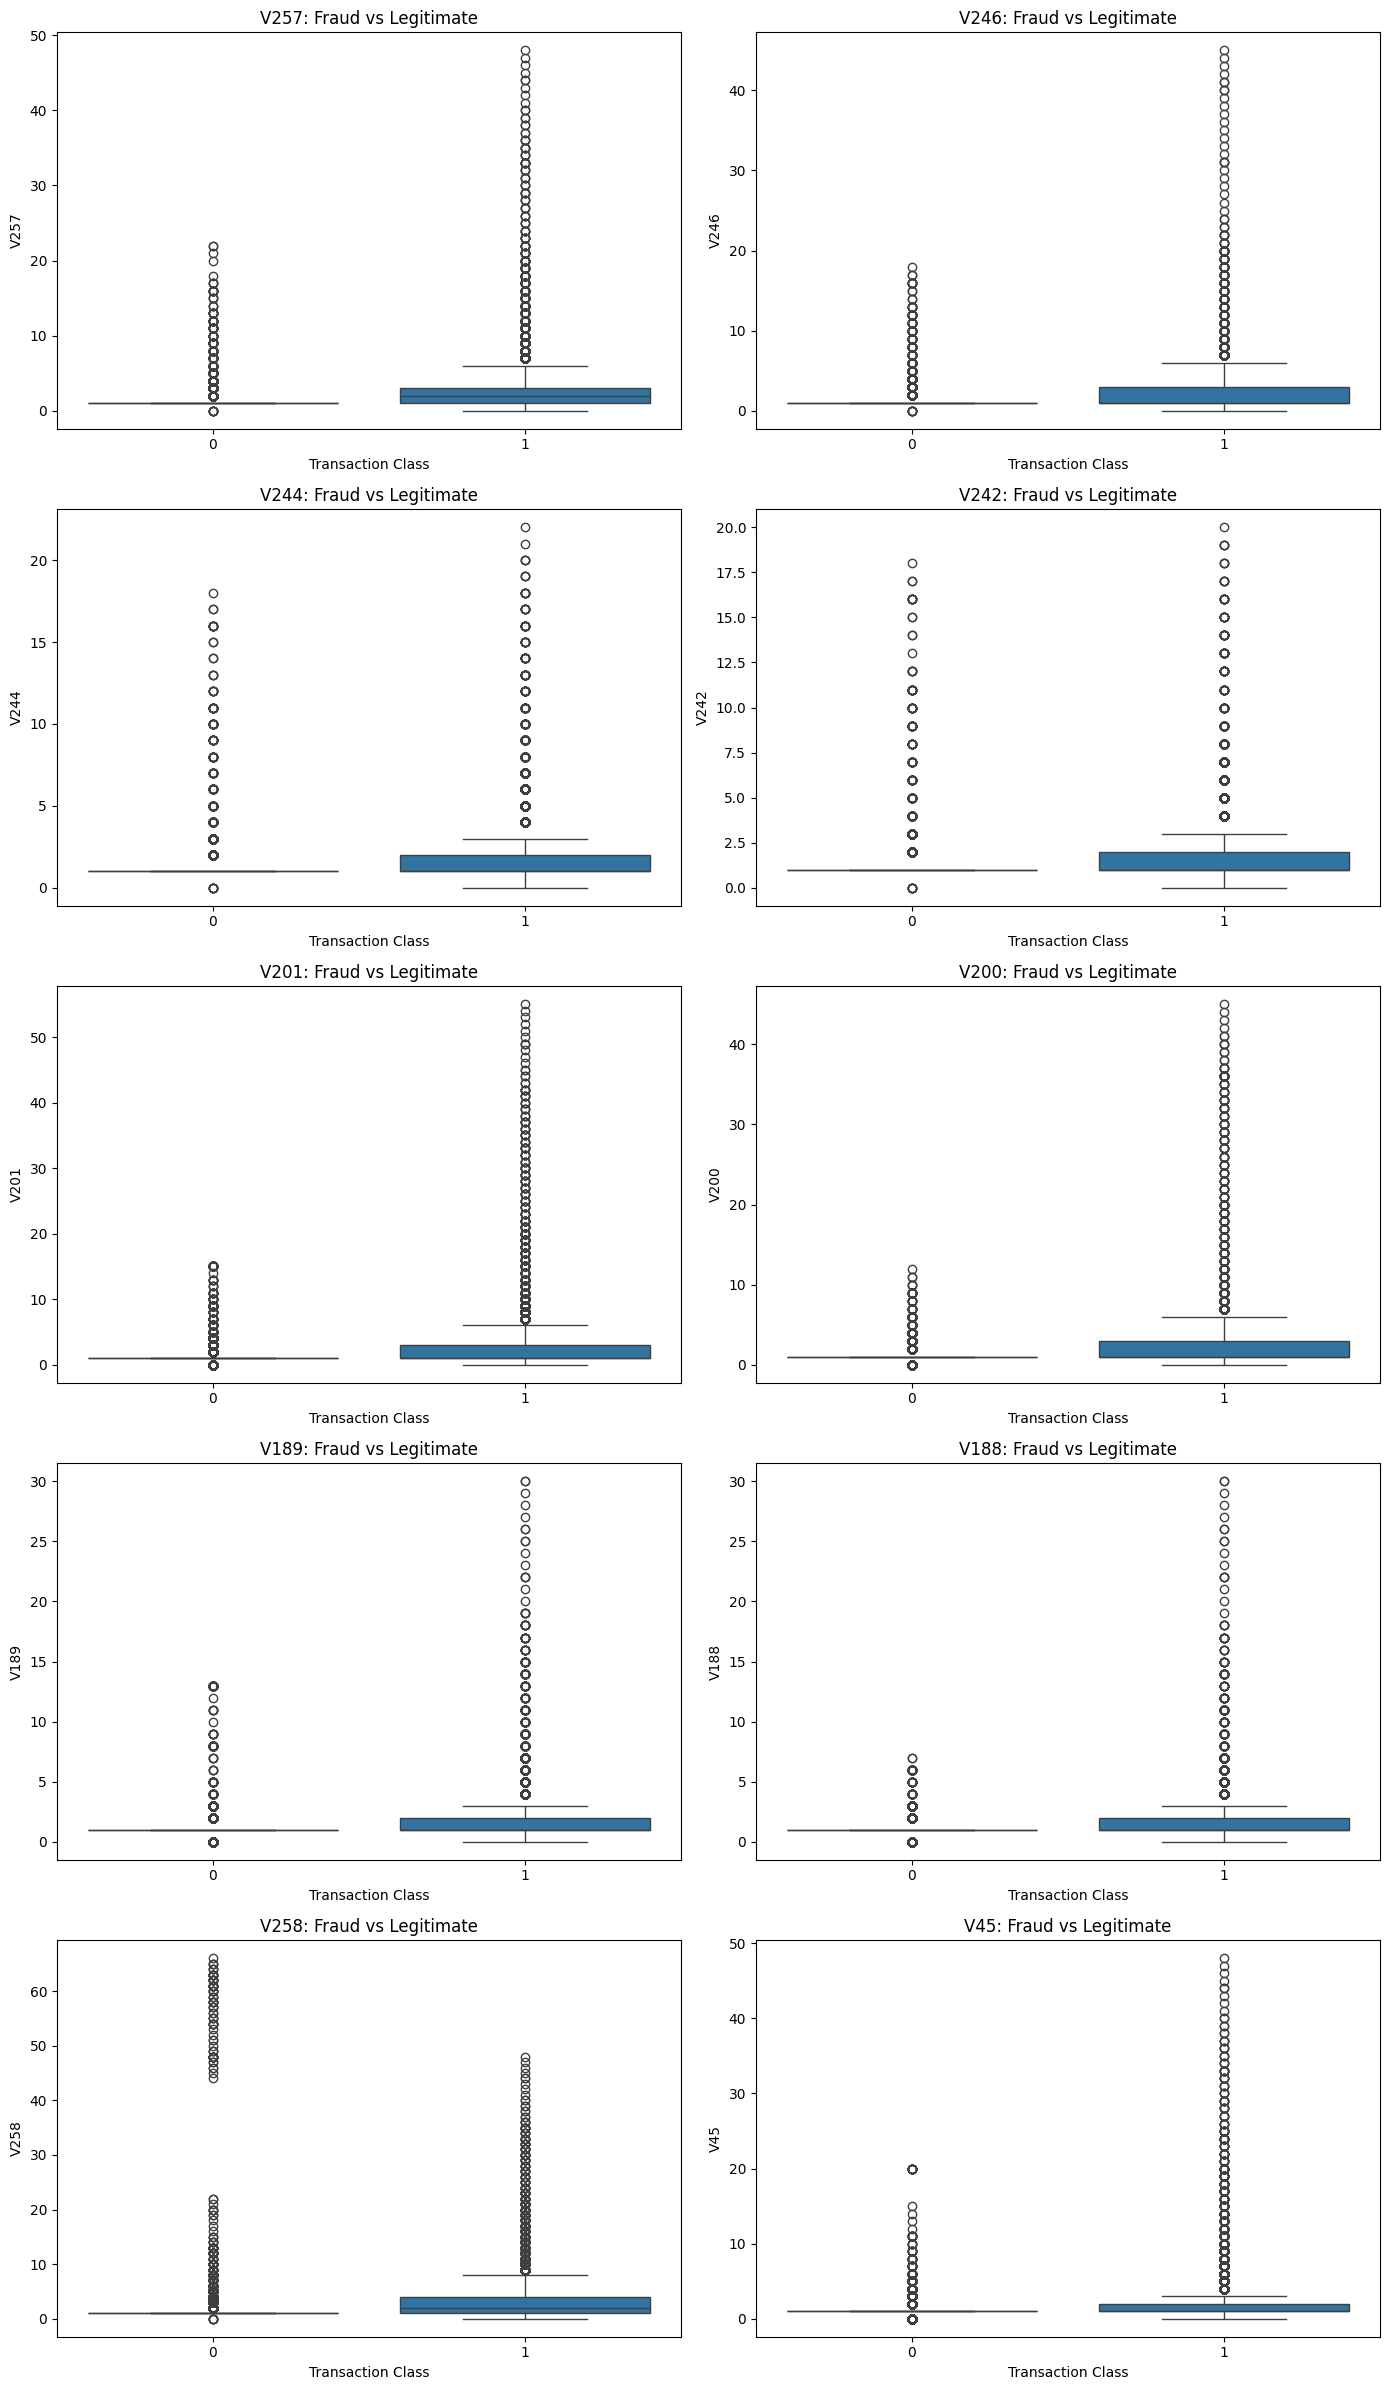

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

top_numerical_features = (
    numerical_association
    .head(10)
    .index
    .tolist()
)

fig, axes = plt.subplots(5, 2, figsize=(14, 24))

for ax, feature in zip(axes.flatten(), top_numerical_features):
    sns.boxplot(
        data=df,
        x="isFraud",
        y=feature,
        ax=ax
    )
    
    ax.set_title(f"{feature}: Fraud vs Legitimate")
    ax.set_xlabel("Transaction Class")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

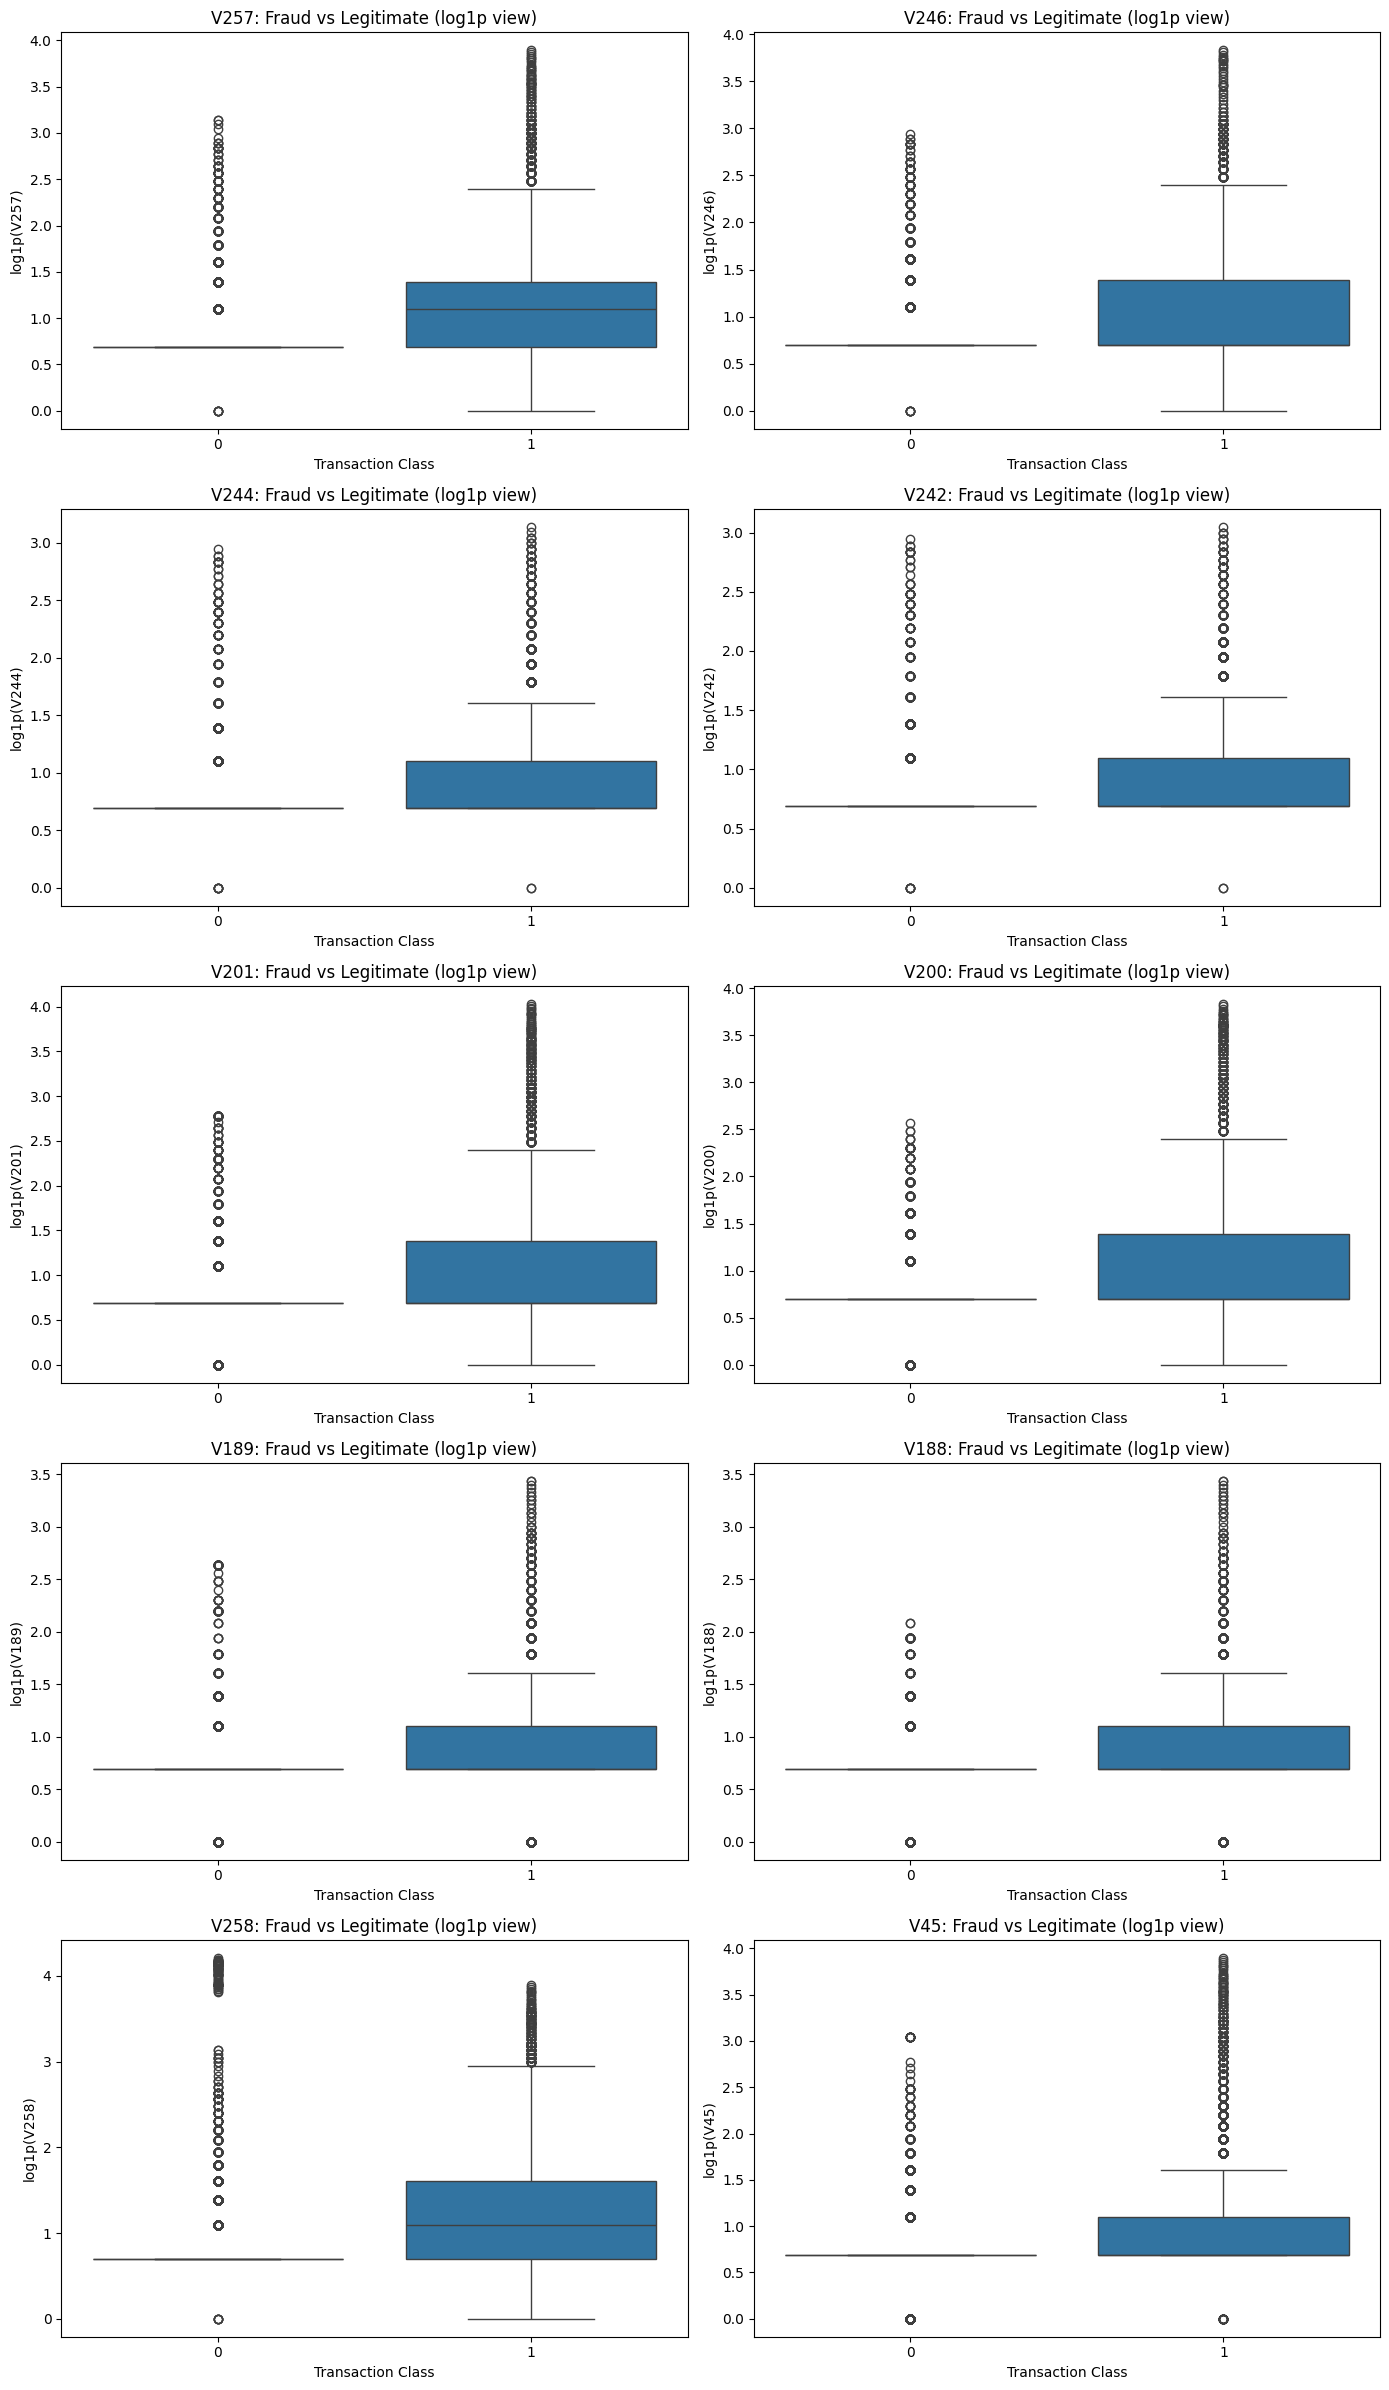

In [73]:
fig, axes = plt.subplots(5, 2, figsize=(14, 24))

for ax, feature in zip(axes.flatten(), top_numerical_features):
    
    plot_data = df[
        ["isFraud", feature]
    ].dropna().copy()
    
    plot_data["transformed"] = np.log1p(plot_data[feature])
    
    sns.boxplot(
        data=plot_data,
        x="isFraud",
        y="transformed",
        ax=ax
    )
    
    ax.set_title(f"{feature}: Fraud vs Legitimate (log1p view)")
    ax.set_xlabel("Transaction Class")
    ax.set_ylabel(f"log1p({feature})")

plt.tight_layout()
plt.show()

## Distribution and Outlier Analysis: Final Findings

### Observation

- The original boxplots showed substantial compression of the fraud distributions because several V-features contain highly skewed values and extreme observations.
- A log1p transformation used for visualization revealed clearer differences between fraudulent and legitimate transactions.
- Features such as `V257`, `V246`, `V244`, `V242`, `V201`, and `V200` show noticeable shifts in their distributions between the two transaction classes.
- Several features contain substantial outliers in both classes, although the fraud class generally shows a broader upper-tail distribution.
- The distributions still overlap considerably, indicating that none of these individual features should be treated as a standalone fraud rule.

### Interpretation

The strongest numerical features exhibit non-normal and highly skewed distributions, with meaningful differences between fraudulent and legitimate transactions.

The log1p visualization improves the interpretability of these distributions, but the transformation itself does not establish that the underlying features must be transformed for every model.

### Data-Science Implication

- Outliers should not be removed automatically because extreme values may contain useful fraud-related information.
- Log transformations may be useful for models sensitive to feature distributions, particularly the Logistic Regression baseline.
- Tree-based models can generally capture non-linear relationships without requiring normally distributed features.
- Anonymized V-features will continue to be evaluated based on their statistical behavior rather than assumed business meaning.

### Decision

- Retain the original V-features for now.
- Do not remove extreme observations solely because they are statistical outliers.
- Consider `log1p` transformations selectively during model-specific preprocessing.
- Continue with correlation and redundancy analysis before final feature selection.

# Step 6.6 — Correlation & Redundancy Analysis

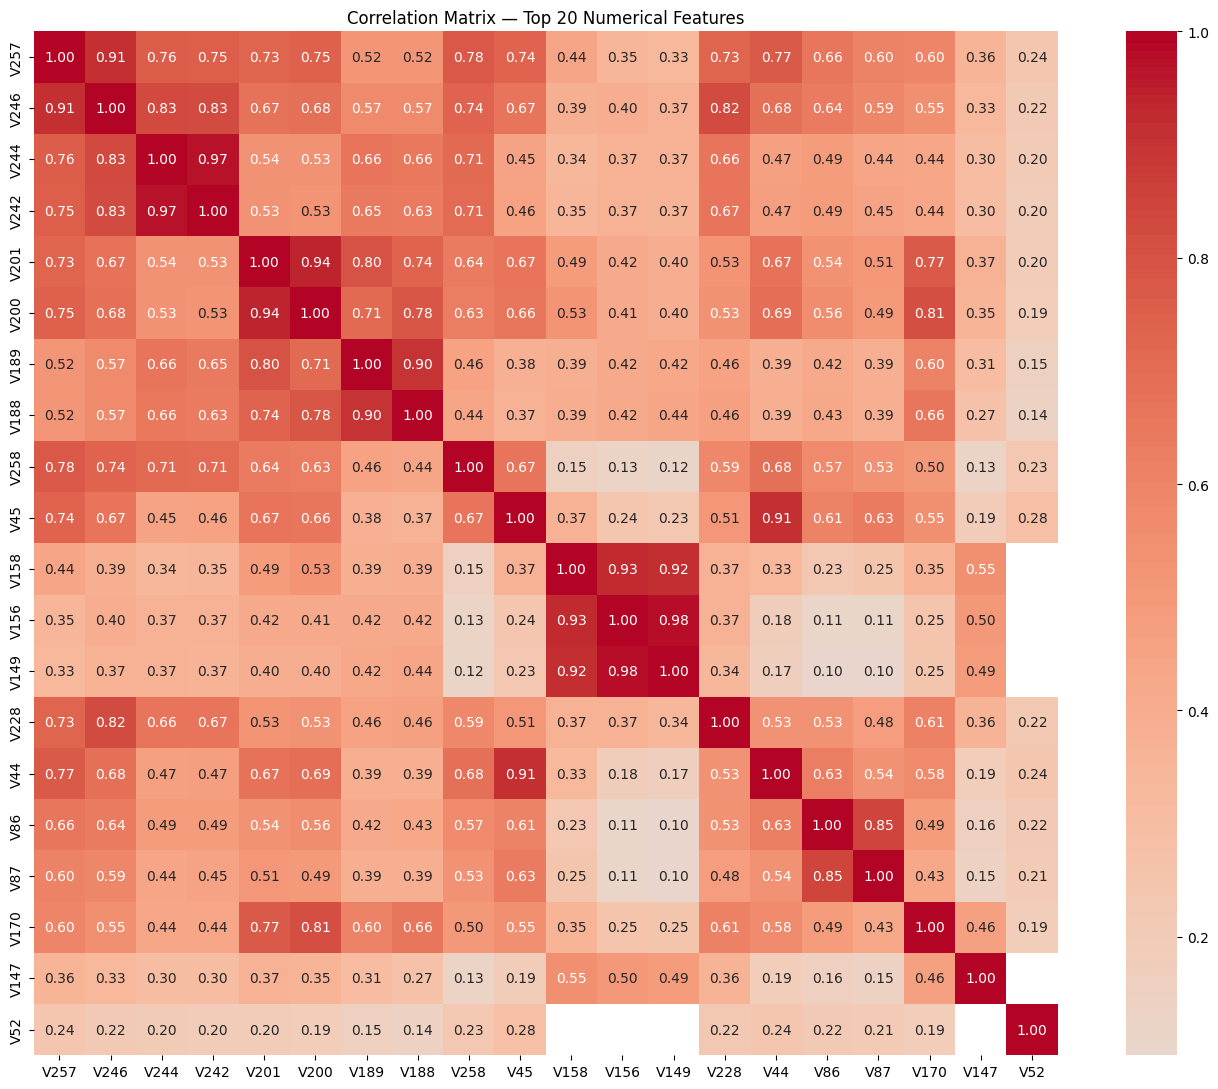

In [74]:
# Select the 20 strongest numerical features identified during screening
top_20_features = (
    numerical_association
    .head(20)
    .index
    .tolist()
)

# Calculate correlation matrix
top_20_corr = df[top_20_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 11))

sns.heatmap(
    top_20_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix — Top 20 Numerical Features")
plt.tight_layout()
plt.show()

In [75]:
# Calculate absolute correlations among all numerical candidate features
corr_matrix = df[numeric_features].corr().abs()

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Extract feature pairs with correlation >= 0.90
high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "absolute_correlation"
]

high_corr_pairs = high_corr_pairs.sort_values(
    "absolute_correlation",
    ascending=False
)

print("Highly correlated feature pairs (|r| >= 0.90):")
print(high_corr_pairs.head(30))

print(
    "\nNumber of highly correlated pairs:",
    len(high_corr_pairs)
)

Highly correlated feature pairs (|r| >= 0.90):
      feature_1 feature_2  absolute_correlation
9656         D4       D12              0.999999
37488       V95      V322              0.999949
37755       V96      V323              0.999948
38021       V97      V324              0.999947
39069      V101      V322              0.999698
69273      V279      V322              0.999624
37267       V95      V101              0.999594
69244      V279      V293              0.999568
5806         C7       C12              0.999489
69357      V280      V324              0.999464
70330      V293      V322              0.999403
53728      V167      V177              0.999364
39590      V103      V324              0.999258
40110      V105      V329              0.999101
39040      V101      V293              0.998919
39330      V102      V323              0.998828
70467      V295      V324              0.998827
37800       V97      V103              0.998789
37445       V95      V279              0.

## Step 6.6.2 — Let's quantify the redundancy

In [76]:
thresholds = [0.90, 0.95, 0.99]

print("Correlation redundancy summary\n")

for threshold in thresholds:
    
    pairs = high_corr_pairs[
        high_corr_pairs["absolute_correlation"] >= threshold
    ]
    
    unique_features = set(
        pairs["feature_1"]
    ).union(
        set(pairs["feature_2"])
    )
    
    print(f"|r| >= {threshold:.2f}")
    print(f"  Correlated pairs: {len(pairs):,}")
    print(f"  Unique features involved: {len(unique_features):,}")
    print()

Correlation redundancy summary

|r| >= 0.90
  Correlated pairs: 1,376
  Unique features involved: 266

|r| >= 0.95
  Correlated pairs: 573
  Unique features involved: 191

|r| >= 0.99
  Correlated pairs: 146
  Unique features involved: 69



In [77]:
print("Top 50 most highly correlated feature pairs:\n")

print(
    high_corr_pairs[
        high_corr_pairs["absolute_correlation"] >= 0.99
    ].head(50).to_string(index=False)
)

Top 50 most highly correlated feature pairs:

feature_1 feature_2  absolute_correlation
       D4       D12              0.999999
      V95      V322              0.999949
      V96      V323              0.999948
      V97      V324              0.999947
     V101      V322              0.999698
     V279      V322              0.999624
      V95      V101              0.999594
     V279      V293              0.999568
       C7       C12              0.999489
     V280      V324              0.999464
     V293      V322              0.999403
     V167      V177              0.999364
     V103      V324              0.999258
     V105      V329              0.999101
     V101      V293              0.998919
     V102      V323              0.998828
     V295      V324              0.998827
      V97      V103              0.998789
      V95      V279              0.998710
     V280      V295              0.998623
     V294      V323              0.998592
      V95      V293           

## Step 6.6.3 — Identify redundancy groups

The correlation analysis identified substantial redundancy among the numerical
features.

Rather than treating each correlated pair independently, highly correlated
features are grouped into connected redundancy groups using an absolute
correlation threshold of 0.99.

These groups represent sets of features that contain very similar numerical
information.

The purpose of this analysis is to identify potential redundancy, not to
automatically remove features.

Final feature reduction will consider:

- Predictive contribution
- Missingness
- Temporal stability
- Redundancy
- Model performance
- Availability at prediction time

In [78]:
# Use the strongest correlation threshold for near-duplicate screening
redundancy_threshold = 0.99

redundancy_pairs = high_corr_pairs[
    high_corr_pairs["absolute_correlation"] >= redundancy_threshold
].copy()

# Build a graph of correlated features
feature_graph = {}

for _, row in redundancy_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    feature_graph.setdefault(f1, set()).add(f2)
    feature_graph.setdefault(f2, set()).add(f1)

# Find connected groups
visited = set()
redundancy_groups = []

for feature in feature_graph:
    
    if feature in visited:
        continue
    
    group = set()
    stack = [feature]
    
    while stack:
        current = stack.pop()
        
        if current in visited:
            continue
        
        visited.add(current)
        group.add(current)
        
        for neighbor in feature_graph.get(current, []):
            if neighbor not in visited:
                stack.append(neighbor)
    
    redundancy_groups.append(sorted(group))

# Sort largest groups first
redundancy_groups = sorted(
    redundancy_groups,
    key=len,
    reverse=True
)

print("Number of redundancy groups:", len(redundancy_groups))

print("\nLargest redundancy groups:")

for i, group in enumerate(redundancy_groups[:20], start=1):
    print(f"Group {i}: {len(group)} features")
    print(group)

Number of redundancy groups: 14

Largest redundancy groups:
Group 1: 19 features
['V102', 'V103', 'V127', 'V128', 'V133', 'V134', 'V280', 'V294', 'V295', 'V307', 'V308', 'V317', 'V318', 'V323', 'V324', 'V332', 'V333', 'V96', 'V97']
Group 2: 16 features
['V101', 'V126', 'V132', 'V143', 'V164', 'V167', 'V177', 'V202', 'V211', 'V279', 'V293', 'V306', 'V316', 'V322', 'V331', 'V95']
Group 3: 5 features
['V217', 'V219', 'V231', 'V232', 'V233']
Group 4: 4 features
['V105', 'V296', 'V298', 'V329']
Group 5: 4 features
['C1', 'C11', 'C2', 'C6']
Group 6: 4 features
['V168', 'V178', 'V179', 'V213']
Group 7: 3 features
['V106', 'V299', 'V330']
Group 8: 2 features
['D12', 'D4']
Group 9: 2 features
['C12', 'C7']
Group 10: 2 features
['C10', 'C8']
Group 11: 2 features
['V266', 'V269']
Group 12: 2 features
['V17', 'V18']
Group 13: 2 features
['V214', 'V276']
Group 14: 2 features
['V180', 'V182']


## Step 6.6 — Correlation and Redundancy: Final Findings

### Observation

- The numerical feature set contains substantial redundancy.
- At an absolute correlation threshold of **0.90**, there are **1,376 highly correlated feature pairs involving 266 unique features**.
- At **0.95**, there are **573 highly correlated pairs involving 191 unique features**.
- At **0.99**, there are **146 near-duplicate pairs involving 69 unique features**.
- These relationships form **14 distinct redundancy groups**.
- The largest redundancy groups contain **19 and 16 features**, respectively, demonstrating that some V-features form large clusters of highly similar numerical information.
- Several relationships are extremely strong, including `D4`–`D12` with a correlation of approximately **0.999999** and multiple V-feature pairs with correlations above **0.999**.

### Interpretation

The dataset contains considerable numerical redundancy, particularly among the anonymized V-features.

Highly correlated features may represent similar statistical information, but correlation alone does not establish that one feature is unnecessary for fraud prediction.

### Data-Science Implication

Including every highly correlated feature may increase model complexity and computational cost without providing proportional additional information.

However, removing features solely on the basis of correlation could discard features that differ in:

- Missingness
- Predictive contribution
- Temporal stability
- Availability at prediction time

Therefore, correlation will be used as a **feature-reduction screening criterion rather than an automatic deletion rule**.

### Decision

- Flag the identified redundancy groups for feature selection.
- Do not remove correlated features at the EDA stage.
- During feature engineering and modeling, evaluate representative features from highly redundant groups.
- Prefer features with stronger predictive contribution, better availability, and greater temporal stability when reducing redundancy.
- Reassess redundancy after preprocessing and feature engineering.

# Step 6.7 — Temporal Stability

Fraud patterns may change over time, so a feature that appears predictive
across the entire dataset may not maintain the same relationship throughout
the observation period.

To assess temporal stability, the strongest numerical features will be
evaluated separately across weekly transaction periods.

The analysis examines whether the direction and magnitude of each feature's
association with fraud remain reasonably consistent over time.

This is an exploratory stability check. Final feature selection will use
training-period information only and will be confirmed using chronological
validation.

In [79]:
# Calculate weekly correlation between each top numerical feature and fraud
weekly_feature_corr = []

for week, week_data in df.groupby("time_week"):
    
    for feature in top_numerical_features:
        
        correlation = week_data[feature].corr(
            week_data["isFraud"]
        )
        
        weekly_feature_corr.append({
            "time_week": week,
            "feature": feature,
            "correlation": correlation
        })

weekly_feature_corr = pd.DataFrame(weekly_feature_corr)

print("Weekly correlation table shape:")
print(weekly_feature_corr.shape)

print("\nFirst 20 rows:")
print(weekly_feature_corr.head(20))

Weekly correlation table shape:
(260, 3)

First 20 rows:
    time_week feature  correlation
0           0    V257     0.314403
1           0    V246     0.249110
2           0    V244     0.239039
3           0    V242     0.217964
4           0    V201     0.347732
5           0    V200     0.270426
6           0    V189     0.318952
7           0    V188     0.226838
8           0    V258     0.074917
9           0     V45     0.237941
10          1    V257     0.200799
11          1    V246     0.130084
12          1    V244     0.126207
13          1    V242     0.120658
14          1    V201     0.337608
15          1    V200     0.323427
16          1    V189     0.279574
17          1    V188     0.258665
18          1    V258     0.058050
19          1     V45     0.253269


In [80]:
temporal_stability = (
    weekly_feature_corr
    .groupby("feature")["correlation"]
    .agg(
        mean_correlation="mean",
        std_correlation="std",
        min_correlation="min",
        max_correlation="max",
        positive_weeks=lambda x: (x > 0).sum(),
        valid_weeks="count"
    )
)

temporal_stability["positive_week_pct"] = (
    temporal_stability["positive_weeks"]
    / temporal_stability["valid_weeks"]
    * 100
)

temporal_stability = temporal_stability.sort_values(
    "mean_correlation",
    ascending=False
)

print(temporal_stability)

         mean_correlation  std_correlation  min_correlation  max_correlation  \
feature                                                                        
V257             0.407013         0.078548         0.200799         0.512263   
V258             0.399816         0.119288         0.058050         0.522470   
V246             0.390720         0.084190         0.130084         0.491164   
V244             0.377630         0.076847         0.126207         0.493198   
V242             0.375704         0.080387         0.120658         0.497707   
V200             0.356830         0.064564         0.220488         0.468880   
V201             0.354071         0.063426         0.179395         0.456543   
V189             0.316687         0.071870         0.136334         0.446410   
V188             0.313489         0.066640         0.168856         0.498674   
V45              0.289448         0.051926         0.203247         0.416690   

         positive_weeks  valid_weeks  p

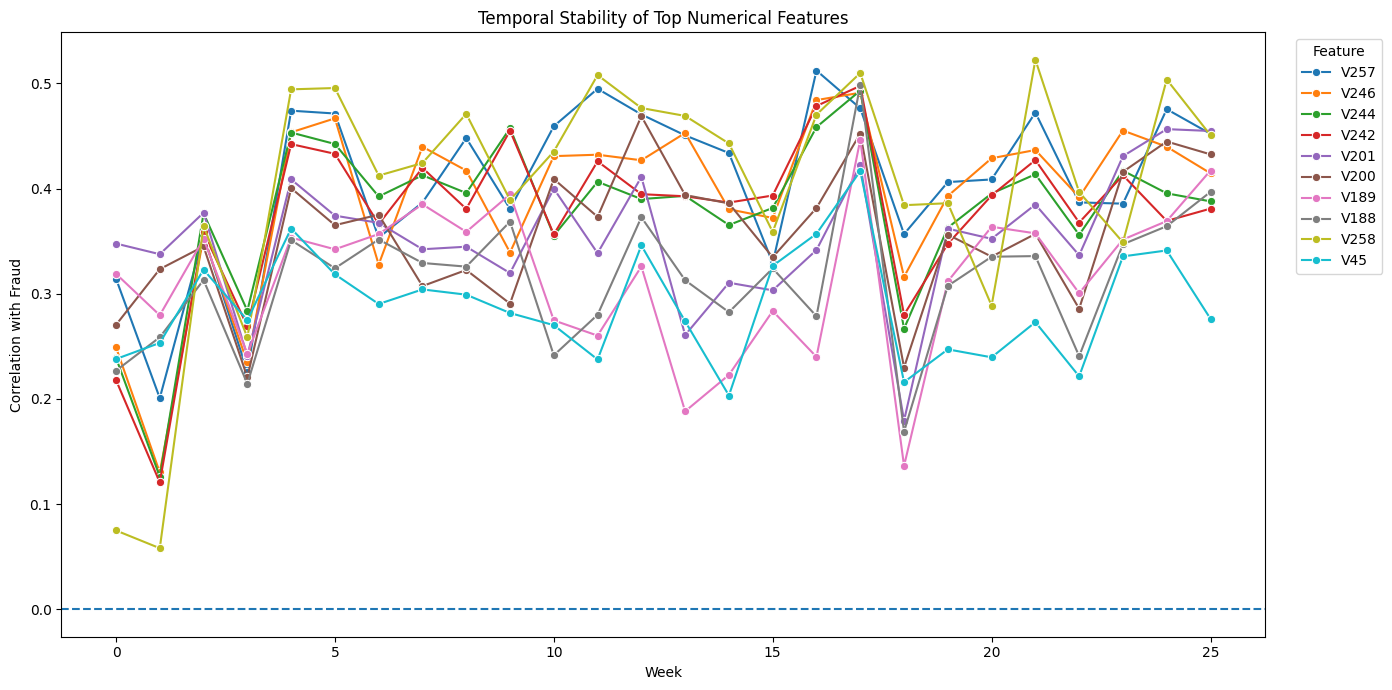

In [81]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=weekly_feature_corr,
    x="time_week",
    y="correlation",
    hue="feature",
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Temporal Stability of Top Numerical Features")
plt.xlabel("Week")
plt.ylabel("Correlation with Fraud")
plt.legend(
    title="Feature",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

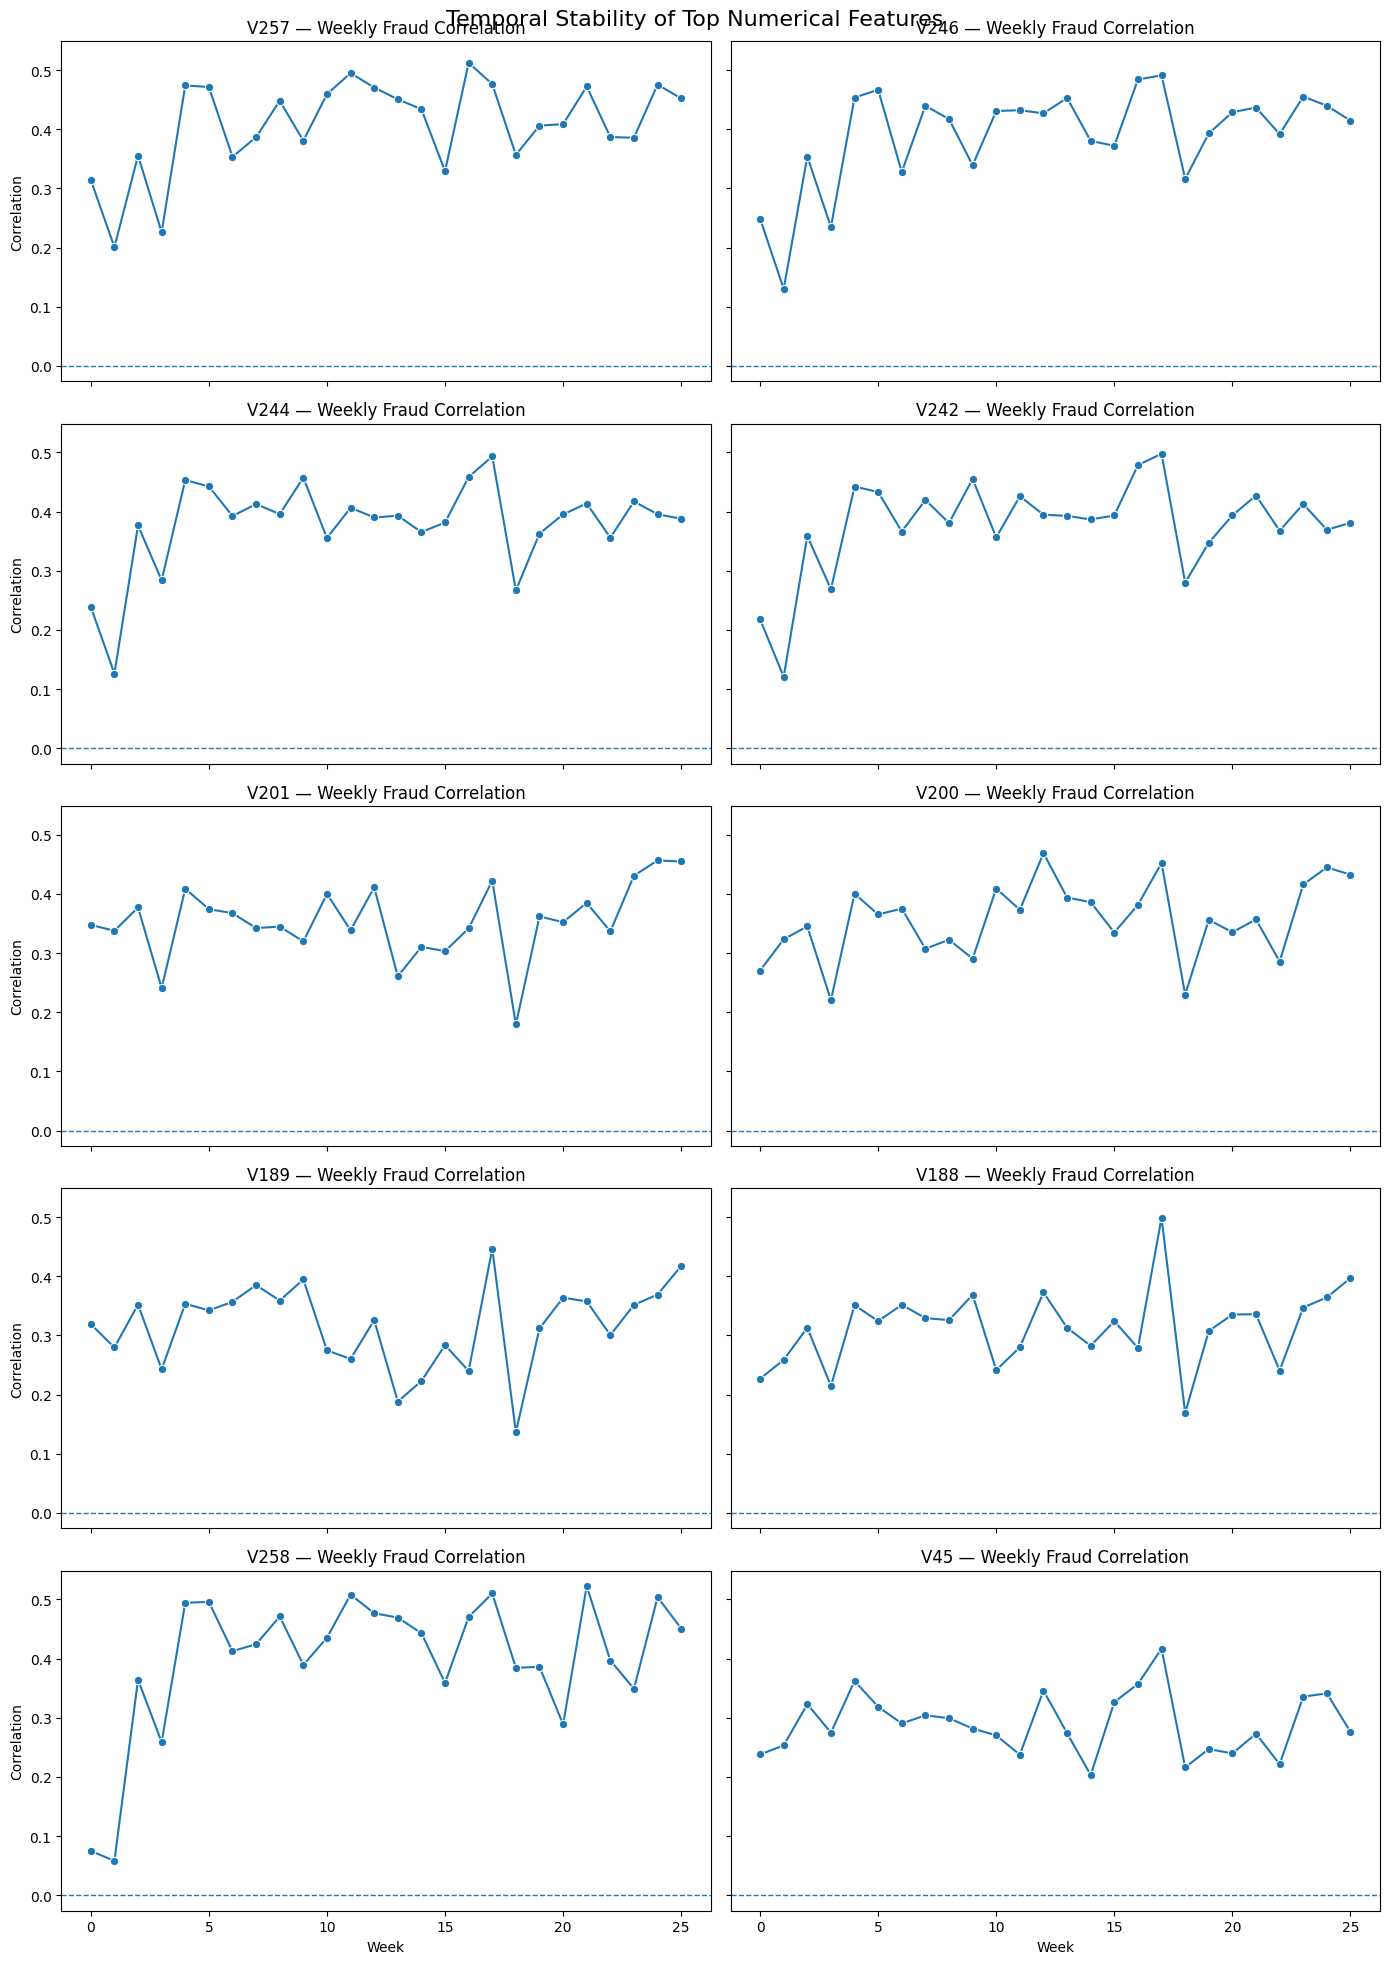

In [83]:
fig, axes = plt.subplots(
    5, 2,
    figsize=(14, 20),
    sharex=True,
    sharey=True
)

for ax, feature in zip(
    axes.flatten(),
    top_numerical_features
):

    subset = weekly_feature_corr[
        weekly_feature_corr["feature"] == feature
    ]

    sns.lineplot(
        data=subset,
        x="time_week",
        y="correlation",
        marker="o",
        ax=ax
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(f"{feature} — Weekly Fraud Correlation")
    ax.set_xlabel("Week")
    ax.set_ylabel("Correlation")

plt.suptitle(
    "Temporal Stability of Top Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 6.7 — Temporal Stability: Final Findings

### Observation

- The top 10 numerical features maintain a positive association with fraud
  across all **26 weekly periods**.
- Every feature has a **100% positive-week rate**, indicating that none of the
  selected features reverses its observed relationship with fraud during the
  observation period.
- `V257` has the strongest average weekly correlation at approximately
  **0.407**, followed by `V258` at **0.400** and `V246` at **0.391**.
- The strength of the correlations varies across weeks, indicating that the
  magnitude of the relationship is not completely stable.
- `V258` shows the largest variation, with a standard deviation of
  approximately **0.119** and a minimum weekly correlation of approximately
  **0.058**.
- Other features such as `V200`, `V201`, and `V45` show comparatively lower
  variation in their weekly correlations.
- Several features show simultaneous increases and decreases in association
  across particular periods, indicating that fraud-related patterns can vary
  over time.

### Interpretation

The strongest numerical features demonstrate **directional temporal stability**:
their association with fraud remains positive throughout the observation
period.

However, their predictive strength is not constant. This indicates that the
fraud process may exhibit temporal variation even when the overall direction of
the feature relationship remains consistent.

### Data-Science Implication

Temporal stability supports retaining these features as candidate predictors.

However, global feature rankings should not be treated as permanently valid.
Feature usefulness should be reassessed using chronological validation so that
the model is evaluated on future transactions rather than randomly mixed
observations.

### Decision

- Retain the strongest numerical features as candidate predictors.
- Treat `V257`, `V246`, `V244`, `V242`, `V201`, `V200`, `V189`, `V188`, and
  `V45` as relatively stable candidate signals.
- Treat `V258` as a strong but comparatively more variable signal.
- Use chronological train-validation splitting during modeling.
- Reassess feature importance and predictive performance on future periods.

## Step 6.8 — Final EDA Conclusions and Feature Decisions

The EDA established the main characteristics of the IEEE-CIS fraud dataset and
identified candidate signals for fraud prediction.

Feature decisions are based on:

- Data quality
- Fraud association
- Missingness
- Redundancy
- Temporal stability
- Availability at the transaction prediction point
- Interpretability and practical usefulness

These decisions are preliminary. Final feature selection will occur after
feature engineering and chronological model validation.

### Feature Decision Matrix

| Feature / Family | EDA Finding | Decision | Planned Treatment |
|---|---|---|---|
| `TransactionID` | Unique transaction identifier | Exclude from modeling | Retain only for identification and joins |
| `TransactionDT` | Primary time variable; fraud prevalence varies over time | Retain | Derive time-based features |
| `TransactionAmt` | Right-skewed and associated with fraud | Retain | Consider log transformation |
| `ProductCD` | Meaningful differences in fraud prevalence | Retain | Categorical encoding |
| `card4`, `card6` | Meaningful fraud-rate differences | Retain | Categorical encoding |
| `P_emaildomain`, `R_emaildomain` | Fraud association with domain categories | Retain | Missing/rare-category handling |
| `DeviceType` | Meaningful fraud-rate differences | Retain | Categorical encoding + missing handling |
| `DeviceInfo` | High cardinality with strong associations | Retain initially | Frequency/rare-category representation |
| `M1`–`M9` | Several features show useful categorical separation | Retain initially | Categorical encoding + missing handling |
| Categorical `id_*` | Several features show strong fraud associations | Retain initially | Encoding + missing handling |
| Numerical `id_*` | High missingness in several features | Investigate | Evaluate predictive value and availability |
| D-features | Some strong redundancy but no evidence of simple time encoding | Retain initially | Reassess redundancy during feature selection |
| Top V-features | Strong fraud association and positive association across all 26 weeks | Retain initially | Feature selection + redundancy analysis |
| Highly correlated numerical groups | Significant redundancy | Do not automatically delete | Reduce only after evaluating predictive contribution |
| EDA helper columns | Created for analysis only | Exclude from modeling unless deliberately transformed | Remove from final feature matrix |

In [84]:
eda_helper_columns = [
    "has_identity",
    "time_period",
    "time_days",
    "amount_range",
    "transaction_day",
    "time_week"
]

print("EDA helper columns:")
for col in eda_helper_columns:
    print("-", col)

print("\nCurrent analytical dataset shape:", df.shape)

EDA helper columns:
- has_identity
- time_period
- time_days
- amount_range
- transaction_day
- time_week

Current analytical dataset shape: (590540, 440)
